Imports and settings

In [6]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp
from IPython.display import display
from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

OUTPUT_DIR = BASE_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "reports"

for path in [TABLES_DIR, PLOTS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TARGET_COL = "loan_paid_back"
ID_COL = "id"

TOP_NUMERIC_PLOTS = 10
TOP_CATEGORICAL_PLOTS = 8
HIGH_CARDINALITY_THRESHOLD = 30
NEAR_CONSTANT_THRESHOLD = 0.98
RANDOM_STATE = 42

DATE_KEYWORDS = ["date", "time", "timestamp", "month", "year", "day"]
LEAKAGE_KEYWORDS = [
    "paid", "payback", "repay", "repayment", "status", "default", "settled",
    "closed", "chargeoff", "principal_paid", "interest_paid", "recovery",
    "delinquent", "collection", "outcome"
]
SUSPICIOUS_TEXT_VALUES = {"unknown", "?", "n/a", "na", "none", "null", "missing", "unk", "nan", "-"}


def save_csv(df: pd.DataFrame, filename: str) -> None:
    df.to_csv(TABLES_DIR / filename, index=False, encoding="utf-8")


def write_text(filename: str, text: str) -> None:
    (REPORTS_DIR / filename).write_text(text, encoding="utf-8")


def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def example_values(series: pd.Series, n: int = 3) -> str:
    values = (
        series.dropna()
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .unique()
        .tolist()
    )
    return " | ".join(values[:n])


def normalize_categorical(series: pd.Series) -> pd.Series:
    return series.fillna("[Missing]").astype(str).str.strip()


def pretty_join(values, limit: int = 20) -> str:
    values = list(values)
    return ", ".join(map(str, values[:limit])) if values else "None"


def guess_role(column_name: str) -> str:
    col = column_name.lower()
    if col == TARGET_COL:
        return "target"
    if col == ID_COL or col.endswith("_id"):
        return "identifier"
    return "feature"


def guess_type_group(column_name: str, series: pd.Series) -> str:
    col = column_name.lower()

    if col == TARGET_COL:
        return "target"
    if col == ID_COL or col.endswith("_id"):
        return "identifier"
    if any(keyword in col for keyword in DATE_KEYWORDS):
        return "date/time"

    if pd.api.types.is_numeric_dtype(series):
        unique_count = series.nunique(dropna=True)
        if pd.api.types.is_integer_dtype(series) and unique_count <= 20:
            return "numeric discrete"
        return "numeric continuous"

    if str(series.dtype) in ["object", "category", "string", "bool"]:
        return "categorical nominal"

    return "probably useless"


def guess_meaning(column_name: str) -> str:
    col = column_name.lower()

    if col == TARGET_COL:
        return "Binary target label"
    if col == ID_COL or col.endswith("_id"):
        return "Identifier"
    if any(keyword in col for keyword in DATE_KEYWORDS):
        return "Date or time field"
    if any(keyword in col for keyword in ["amount", "amt", "balance", "principal", "interest", "payment", "income", "salary", "loan"]):
        return "Financial amount or loan-related value"
    if any(keyword in col for keyword in ["rate", "ratio", "pct", "percent", "score"]):
        return "Rate, ratio, percentage or score"
    if any(keyword in col for keyword in ["count", "num", "term", "months", "years", "days", "duration", "age"]):
        return "Count, duration or discrete numeric feature"

    return "Manual review needed"


def leakage_name_flag(column_name: str) -> bool:
    col = column_name.lower()
    return any(keyword in col for keyword in LEAKAGE_KEYWORDS)

Load data

In [7]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission_df = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
print(f"sample_submission shape: {sample_submission_df.shape}")

display(train_df.head())
display(test_df.head())
display(sample_submission_df.head())

print("TRAIN COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST COLUMNS:")
print(test_df.columns.tolist())

print("\nSAMPLE SUBMISSION COLUMNS:")
print(sample_submission_df.columns.tolist())

train_dtypes = train_df.dtypes.reset_index()
train_dtypes.columns = ["column", "dtype"]
display(train_dtypes)
save_csv(train_dtypes, "train_dtypes.csv")

target_presence = pd.DataFrame(
    {
        "dataset": ["train", "test", "sample_submission"],
        "has_target": [
            TARGET_COL in train_df.columns,
            TARGET_COL in test_df.columns,
            TARGET_COL in sample_submission_df.columns,
        ],
    }
)
display(target_presence)
save_csv(target_presence, "target_presence_check.csv")

id_check = pd.DataFrame(
    {
        "dataset": ["train", "test", "sample_submission"],
        "has_id": [
            ID_COL in train_df.columns,
            ID_COL in test_df.columns,
            ID_COL in sample_submission_df.columns,
        ],
        "id_is_unique": [
            train_df[ID_COL].is_unique if ID_COL in train_df.columns else None,
            test_df[ID_COL].is_unique if ID_COL in test_df.columns else None,
            sample_submission_df[ID_COL].is_unique if ID_COL in sample_submission_df.columns else None,
        ],
        "duplicate_id_count": [
            train_df[ID_COL].duplicated().sum() if ID_COL in train_df.columns else None,
            test_df[ID_COL].duplicated().sum() if ID_COL in test_df.columns else None,
            sample_submission_df[ID_COL].duplicated().sum() if ID_COL in sample_submission_df.columns else None,
        ],
    }
)
display(id_check)
save_csv(id_check, "id_check.csv")

duplicate_rows_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "duplicate_row_count": [
            train_df.duplicated().sum(),
            test_df.duplicated().sum(),
        ],
    }
)
display(duplicate_rows_summary)
save_csv(duplicate_rows_summary, "duplicate_rows_summary.csv")

expected_test_columns = [col for col in train_df.columns if col != TARGET_COL]
missing_in_test = sorted(set(expected_test_columns) - set(test_df.columns))
extra_in_test = sorted(set(test_df.columns) - set(expected_test_columns))

column_consistency = pd.DataFrame(
    {
        "missing_in_test": pd.Series(missing_in_test),
        "extra_in_test": pd.Series(extra_in_test),
    }
)
display(column_consistency)
save_csv(column_consistency, "column_consistency.csv")

sample_submission_matches_test_ids = (
    sample_submission_df[ID_COL].reset_index(drop=True).astype(str).equals(
        test_df[ID_COL].reset_index(drop=True).astype(str)
    )
    if ID_COL in sample_submission_df.columns and ID_COL in test_df.columns
    else False
)

sample_submission_check = pd.DataFrame(
    {
        "check": [
            "sample_submission_has_id",
            "sample_submission_has_target",
            "sample_submission_id_matches_test"
        ],
        "value": [
            ID_COL in sample_submission_df.columns,
            TARGET_COL in sample_submission_df.columns,
            sample_submission_matches_test_ids,
        ]
    }
)
display(sample_submission_check)
save_csv(sample_submission_check, "sample_submission_check.csv")

column_name_audit = pd.DataFrame({"column": train_df.columns})
column_name_audit["has_leading_or_trailing_spaces"] = column_name_audit["column"].apply(lambda x: x != x.strip())
column_name_audit["has_double_spaces"] = column_name_audit["column"].str.contains(r"\s{2,}", regex=True)
column_name_audit["has_uppercase_letters"] = column_name_audit["column"].apply(lambda x: x != x.lower())
column_name_audit["has_special_characters"] = column_name_audit["column"].str.contains(r"[^A-Za-z0-9_]", regex=True)
column_name_audit["duplicate_column_name"] = column_name_audit["column"].duplicated(keep=False)
display(column_name_audit)
save_csv(column_name_audit, "column_name_audit.csv")

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": "train",
            "rows": train_df.shape[0],
            "columns": train_df.shape[1],
            "has_id": ID_COL in train_df.columns,
            "has_target": TARGET_COL in train_df.columns,
        },
        {
            "dataset": "test",
            "rows": test_df.shape[0],
            "columns": test_df.shape[1],
            "has_id": ID_COL in test_df.columns,
            "has_target": TARGET_COL in test_df.columns,
        },
        {
            "dataset": "sample_submission",
            "rows": sample_submission_df.shape[0],
            "columns": sample_submission_df.shape[1],
            "has_id": ID_COL in sample_submission_df.columns,
            "has_target": TARGET_COL in sample_submission_df.columns,
        },
    ]
)
display(dataset_overview)
save_csv(dataset_overview, "dataset_overview.csv")

sanity_report = f"""
# Loading and sanity check

## Dataset shapes
- train shape: {train_df.shape}
- test shape: {test_df.shape}
- sample_submission shape: {sample_submission_df.shape}

## Target checks
- target in train: {TARGET_COL in train_df.columns}
- target in test: {TARGET_COL in test_df.columns}
- target in sample_submission: {TARGET_COL in sample_submission_df.columns}

## ID checks
- id in train: {ID_COL in train_df.columns}
- id in test: {ID_COL in test_df.columns}
- id in sample_submission: {ID_COL in sample_submission_df.columns}
- train id unique: {train_df[ID_COL].is_unique if ID_COL in train_df.columns else "N/A"}
- test id unique: {test_df[ID_COL].is_unique if ID_COL in test_df.columns else "N/A"}
- sample_submission id unique: {sample_submission_df[ID_COL].is_unique if ID_COL in sample_submission_df.columns else "N/A"}
- sample_submission id matches test: {sample_submission_matches_test_ids}

## Duplicate rows
- train duplicate rows: {train_df.duplicated().sum()}
- test duplicate rows: {test_df.duplicated().sum()}

## Column consistency
- missing in test: {missing_in_test}
- extra in test: {extra_in_test}
"""
write_text("01_loading_and_sanity.md", sanity_report)
print(sanity_report)

train shape: (593994, 13)
test shape: (254569, 12)
sample_submission shape: (254569, 2)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


,id,loan_paid_back
0,593994,0
1,593995,0
2,593996,0
3,593997,0
4,593998,0


TRAIN COLUMNS:
['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back']

TEST COLUMNS:
['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

SAMPLE SUBMISSION COLUMNS:
['id', 'loan_paid_back']


...

,missing_in_test,extra_in_test


,check,value
0,sample_submission_has_id,True
1,sample_submission_has_target,True
2,sample_submission_id_matches_test,True


,column,has_leading_or_trailing_spaces,has_double_spaces,has_uppercase_letters,has_special_characters,duplicate_column_name
0,id,False,False,False,False,False
1,annual_income,False,False,False,False,False
2,debt_to_income_ratio,False,False,False,False,False
3,credit_score,False,False,False,False,False
4,loan_amount,False,False,False,False,False
5,interest_rate,False,False,False,False,False
6,gender,False,False,False,False,False
7,marital_status,False,False,False,False,False
8,education_level,False,False,False,False,False
9,employment_status,False,False,False,False,False


,dataset,rows,columns,has_id,has_target
0,train,593994,13,True,True
1,test,254569,12,True,False
2,sample_submission,254569,2,True,True



# Loading and sanity check

## Dataset shapes
- train shape: (593994, 13)
- test shape: (254569, 12)
- sample_submission shape: (254569, 2)

## Target checks
- target in train: True
- target in test: False
- target in sample_submission: True

## ID checks
- id in train: True
- id in test: True
- id in sample_submission: True
- train id unique: True
- test id unique: True
- sample_submission id unique: True
- sample_submission id matches test: True

## Duplicate rows
- train duplicate rows: 0
- test duplicate rows: 0

## Column consistency
- missing in test: []
- extra in test: []



Data dictionary

In [8]:
data_dictionary_rows = []

for column in train_df.columns:
    series = train_df[column]

    data_dictionary_rows.append(
        {
            "column_name": column,
            "dtype": str(series.dtype),
            "missing_count": int(series.isna().sum()),
            "missing_percent": round(series.isna().mean() * 100, 4),
            "unique_count": int(series.nunique(dropna=True)),
            "example_values": example_values(series, n=3),
            "guessed_meaning": guess_meaning(column),
            "role": guess_role(column),
            "type_group": guess_type_group(column, series),
            "risk_flag": "suspicious / leakage risk" if leakage_name_flag(column) else "",
            "exists_in_test": column in test_df.columns,
            "notes": "",
        }
    )

data_dictionary = pd.DataFrame(data_dictionary_rows)
display(data_dictionary.head(20))
save_csv(data_dictionary, "data_dictionary.csv")

data_dictionary_short = data_dictionary[
    ["column_name", "dtype", "missing_percent", "unique_count", "role", "type_group", "risk_flag", "guessed_meaning"]
].sort_values(["role", "type_group", "column_name"])

display(data_dictionary_short.head(20))
save_csv(data_dictionary_short, "data_dictionary_short.csv")

,column_name,dtype,missing_count,missing_percent,unique_count,example_values,guessed_meaning,role,type_group,risk_flag,exists_in_test,notes
0,id,int64,0,0.0,593994,0 | 1 | 2,Identifier,identifier,identifier,,True,
1,annual_income,float64,0,0.0,119728,29367.99 | 22108.02 | 49566.2,Financial amount or loan-related value,feature,numeric continuous,,True,
2,debt_to_income_ratio,float64,0,0.0,526,0.084 | 0.166 | 0.097,Financial amount or loan-related value,feature,numeric continuous,,True,
3,credit_score,int64,0,0.0,399,736 | 636 | 694,"Rate, ratio, percentage or score",feature,numeric continuous,,True,
4,loan_amount,float64,0,0.0,111570,2528.42 | 4593.1 | 17005.15,Financial amount or loan-related value,feature,numeric continuous,,True,
5,interest_rate,float64,0,0.0,1454,13.67 | 12.92 | 9.76,Financial amount or loan-related value,feature,numeric continuous,,True,
6,gender,object,0,0.0,3,Female | Male | Other,Manual review needed,feature,categorical nominal,,True,
7,marital_status,object,0,0.0,4,Single | Married | Divorced,Manual review needed,feature,categorical nominal,suspicious / leakage risk,True,
8,education_level,object,0,0.0,5,High School | Master's | Bachelor's,Manual review needed,feature,categorical nominal,,True,
9,employment_status,object,0,0.0,5,Self-employed | Employed | Unemployed,Manual review needed,feature,categorical nominal,suspicious / leakage risk,True,


,column_name,dtype,missing_percent,unique_count,role,type_group,risk_flag,guessed_meaning
8,education_level,object,0.0,5,feature,categorical nominal,,Manual review needed
9,employment_status,object,0.0,5,feature,categorical nominal,suspicious / leakage risk,Manual review needed
6,gender,object,0.0,3,feature,categorical nominal,,Manual review needed
11,grade_subgrade,object,0.0,30,feature,categorical nominal,,Manual review needed
10,loan_purpose,object,0.0,8,feature,categorical nominal,,Financial amount or loan-related value
7,marital_status,object,0.0,4,feature,categorical nominal,suspicious / leakage risk,Manual review needed
1,annual_income,float64,0.0,119728,feature,numeric continuous,,Financial amount or loan-related value
3,credit_score,int64,0.0,399,feature,numeric continuous,,"Rate, ratio, percentage or score"
2,debt_to_income_ratio,float64,0.0,526,feature,numeric continuous,,Financial amount or loan-related value
5,interest_rate,float64,0.0,1454,feature,numeric continuous,,Financial amount or loan-related value


Target analysis

,loan_paid_back,count
0,0.0,119500
1,1.0,474494


,loan_paid_back,percentage
0,0.0,20.118048
1,1.0,79.881952


,metric,value
0,majority_class_rate,0.7988
1,imbalance_label,heavily imbalanced
2,baseline_guess_rate,0.7988
3,validation_recommendation,Use stratified split or stratified k-fold


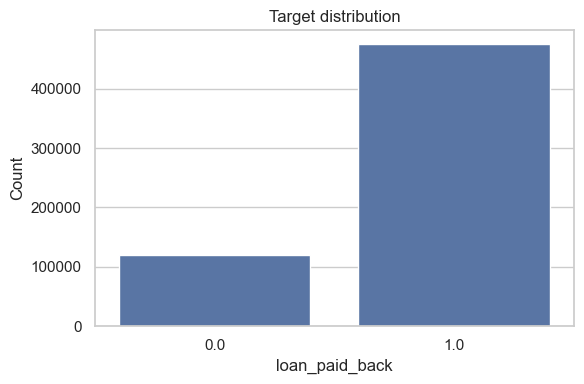


# Target analysis

- target column: loan_paid_back
- imbalance label: heavily imbalanced
- majority-class baseline: 0.7988
- validation recommendation: Use stratified split or stratified k-fold

## Class distribution
 loan_paid_back  count
            0.0 119500
            1.0 474494

## Class percentages
 loan_paid_back  percentage
            0.0   20.118048
            1.0   79.881952



In [9]:
target_numeric = pd.to_numeric(train_df[TARGET_COL], errors="coerce")

target_counts = train_df[TARGET_COL].value_counts(dropna=False).sort_index().reset_index()
target_counts.columns = [TARGET_COL, "count"]
display(target_counts)
save_csv(target_counts, "target_counts.csv")

target_percentages = train_df[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index().mul(100).reset_index()
target_percentages.columns = [TARGET_COL, "percentage"]
display(target_percentages)
save_csv(target_percentages, "target_percentages.csv")

majority_class_rate = train_df[TARGET_COL].value_counts(normalize=True).max()

if majority_class_rate <= 0.60:
    imbalance_label = "balanced"
elif majority_class_rate <= 0.75:
    imbalance_label = "mildly imbalanced"
else:
    imbalance_label = "heavily imbalanced"

validation_recommendation = "Use stratified split or stratified k-fold"

target_summary = pd.DataFrame(
    {
        "metric": ["majority_class_rate", "imbalance_label", "baseline_guess_rate", "validation_recommendation"],
        "value": [round(majority_class_rate, 4), imbalance_label, round(majority_class_rate, 4), validation_recommendation],
    }
)
display(target_summary)
save_csv(target_summary, "target_summary.csv")

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=TARGET_COL)
plt.title("Target distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
save_plot("target_distribution.png")

target_report = f"""
# Target analysis

- target column: {TARGET_COL}
- imbalance label: {imbalance_label}
- majority-class baseline: {majority_class_rate:.4f}
- validation recommendation: {validation_recommendation}

## Class distribution
{target_counts.to_string(index=False)}

## Class percentages
{target_percentages.to_string(index=False)}
"""
write_text("02_target_analysis.md", target_report)
print(target_report)

Split columns by type

In [10]:
numeric_columns = [
    col for col in train_df.select_dtypes(include=["number"]).columns
    if col not in [TARGET_COL, ID_COL]
]

categorical_columns = [
    col for col in train_df.select_dtypes(include=["object", "category", "bool"]).columns
    if col not in [TARGET_COL, ID_COL]
]

other_columns = [
    col for col in train_df.columns
    if col not in numeric_columns + categorical_columns + [TARGET_COL]
]

id_columns = [col for col in train_df.columns if col == ID_COL or col.lower().endswith("_id")]
target_column = TARGET_COL

potential_date_columns = [
    col for col in train_df.columns
    if any(keyword in col.lower() for keyword in DATE_KEYWORDS)
]

potential_leakage_columns = [
    col for col in train_df.columns
    if any(keyword in col.lower() for keyword in LEAKAGE_KEYWORDS)
]

column_groups = {
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "other_columns": other_columns,
    "id_columns": id_columns,
    "target_column": target_column,
    "potential_date_columns": potential_date_columns,
    "potential_leakage_columns": potential_leakage_columns,
}

column_group_summary = pd.DataFrame(
    {
        "group_name": list(column_groups.keys()),
        "count": [
            len(numeric_columns),
            len(categorical_columns),
            len(other_columns),
            len(id_columns),
            1,
            len(potential_date_columns),
            len(potential_leakage_columns),
        ],
    }
)
display(column_group_summary)
save_csv(column_group_summary, "column_group_summary.csv")
write_text("column_groups.json", json.dumps(column_groups, indent=2, ensure_ascii=False))
column_groups

,group_name,count
0,numeric_columns,5
1,categorical_columns,6
2,other_columns,1
3,id_columns,1
4,target_column,1
5,potential_date_columns,0
6,potential_leakage_columns,3


{'numeric_columns': ['annual_income',
  'debt_to_income_ratio',
  'credit_score',
  'loan_amount',
  'interest_rate'],
 'categorical_columns': ['gender',
  'marital_status',
  'education_level',
  'employment_status',
  'loan_purpose',
  'grade_subgrade'],
 'other_columns': ['id'],
 'id_columns': ['id'],
 'target_column': 'loan_paid_back',
 'potential_date_columns': [],
 'potential_leakage_columns': ['marital_status',
  'employment_status',
  'loan_paid_back']}

Data quality checks

In [11]:
train_missing_summary = pd.DataFrame(
    {
        "column": train_df.columns,
        "missing_count_train": train_df.isna().sum().values,
        "missing_percent_train": (train_df.isna().mean() * 100).round(4).values,
    }
).sort_values("missing_percent_train", ascending=False)
display(train_missing_summary.head(20))
save_csv(train_missing_summary, "missing_values_train.csv")

test_missing_summary = pd.DataFrame(
    {
        "column": test_df.columns,
        "missing_count_test": test_df.isna().sum().values,
        "missing_percent_test": (test_df.isna().mean() * 100).round(4).values,
    }
).sort_values("missing_percent_test", ascending=False)
display(test_missing_summary.head(20))
save_csv(test_missing_summary, "missing_values_test.csv")

missing_comparison = train_missing_summary.merge(
    test_missing_summary,
    on="column",
    how="left"
)
missing_comparison["missing_percent_gap"] = (
    missing_comparison["missing_percent_train"] - missing_comparison["missing_percent_test"]
).round(4)
display(missing_comparison.head(20))
save_csv(missing_comparison, "missing_values_comparison.csv")

duplicate_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "duplicate_rows": [train_df.duplicated().sum(), test_df.duplicated().sum()],
        "duplicate_ids": [
            train_df[ID_COL].duplicated().sum() if ID_COL in train_df.columns else None,
            test_df[ID_COL].duplicated().sum() if ID_COL in test_df.columns else None,
        ],
    }
)
display(duplicate_summary)
save_csv(duplicate_summary, "duplicate_summary.csv")

strange_text_rows = []

for col in categorical_columns:
    values = normalize_categorical(train_df[col])
    suspicious_mask = values.str.lower().isin(SUSPICIOUS_TEXT_VALUES)

    if suspicious_mask.sum() > 0:
        strange_text_rows.append(
            {
                "column": col,
                "suspicious_value_count": int(suspicious_mask.sum()),
                "suspicious_examples": " | ".join(values[suspicious_mask].unique()[:5]),
            }
        )

strange_text_summary = pd.DataFrame(
    strange_text_rows,
    columns=["column", "suspicious_value_count", "suspicious_examples"]
)
display(strange_text_summary)
save_csv(strange_text_summary, "strange_text_values.csv")

category_format_issue_rows = []

for col in categorical_columns:
    values = normalize_categorical(train_df[col])

    normalized_to_raw = (
        pd.DataFrame({"raw": values, "normalized": values.str.lower()})
        .groupby("normalized")["raw"]
        .agg(lambda x: sorted(set(x))[:5])
        .reset_index()
    )

    problematic = normalized_to_raw[normalized_to_raw["raw"].apply(len) > 1]

    if not problematic.empty:
        category_format_issue_rows.append(
            {
                "column": col,
                "issue_count": len(problematic),
                "example_variants": " || ".join(
                    problematic["raw"].apply(lambda x: ", ".join(x)).head(3).tolist()
                ),
            }
        )

category_format_issues = pd.DataFrame(
    category_format_issue_rows,
    columns=["column", "issue_count", "example_variants"]
)
display(category_format_issues)
save_csv(category_format_issues, "category_format_issues.csv")

NON_NEGATIVE_NAME_PATTERNS = [
    "age", "income", "salary", "amount", "balance", "principal", "interest",
    "payment", "rate", "ratio", "score", "term", "month", "year", "day", "duration"
]

negative_value_rows = []

for col in numeric_columns:
    col_lower = col.lower()
    if any(pattern in col_lower for pattern in NON_NEGATIVE_NAME_PATTERNS):
        negative_count = int((train_df[col] < 0).sum())
        if negative_count > 0:
            negative_value_rows.append(
                {
                    "column": col,
                    "negative_count": negative_count,
                    "min_value": train_df[col].min(),
                }
            )

negative_values_summary = pd.DataFrame(
    negative_value_rows,
    columns=["column", "negative_count", "min_value"]
)
display(negative_values_summary)
save_csv(negative_values_summary, "negative_values_summary.csv")

ZERO_SUSPICIOUS_PATTERNS = ["age", "income", "salary", "amount", "payment", "term", "month", "year", "duration"]

zero_value_rows = []

for col in numeric_columns:
    col_lower = col.lower()
    if any(pattern in col_lower for pattern in ZERO_SUSPICIOUS_PATTERNS):
        zero_count = int((train_df[col] == 0).sum())
        if zero_count > 0:
            zero_value_rows.append(
                {
                    "column": col,
                    "zero_count": zero_count,
                    "zero_percent": round((train_df[col] == 0).mean() * 100, 4),
                }
            )

zero_values_summary = pd.DataFrame(
    zero_value_rows,
    columns=["column", "zero_count", "zero_percent"]
)
display(zero_values_summary)
save_csv(zero_values_summary, "zero_values_summary.csv")

outlier_rows = []

for col in numeric_columns:
    series = train_df[col].dropna()

    if series.empty:
        continue

    q1 = series.quantile(0.25)
    median = series.quantile(0.50)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_rate = ((series < lower_bound) | (series > upper_bound)).mean()

    outlier_rows.append(
        {
            "column": col,
            "min": series.min(),
            "p01": series.quantile(0.01),
            "q1": q1,
            "median": median,
            "q3": q3,
            "p99": series.quantile(0.99),
            "max": series.max(),
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_rate": round(outlier_rate, 4),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_rate", ascending=False)
display(outlier_summary.head(20))
save_csv(outlier_summary, "outlier_summary.csv")

constant_rows = []

for col in train_df.columns:
    value_counts = train_df[col].value_counts(dropna=False, normalize=True)
    top_frequency = value_counts.iloc[0] if not value_counts.empty else np.nan
    unique_count = train_df[col].nunique(dropna=False)

    constant_rows.append(
        {
            "column": col,
            "unique_count_including_na": int(unique_count),
            "top_value_ratio": round(top_frequency, 4),
            "is_constant": unique_count == 1,
            "is_near_constant_98pct": top_frequency >= NEAR_CONSTANT_THRESHOLD,
        }
    )

constant_summary = pd.DataFrame(constant_rows).sort_values(
    ["is_constant", "is_near_constant_98pct", "top_value_ratio"],
    ascending=[False, False, False]
)
display(constant_summary.head(20))
save_csv(constant_summary, "constant_and_near_constant_columns.csv")

high_cardinality_summary = pd.DataFrame(
    {
        "column": categorical_columns,
        "unique_count": [train_df[col].nunique(dropna=True) for col in categorical_columns],
        "unique_ratio": [round(train_df[col].nunique(dropna=True) / len(train_df), 4) for col in categorical_columns],
    }
).sort_values("unique_count", ascending=False)

high_cardinality_summary["is_high_cardinality"] = high_cardinality_summary["unique_count"] > HIGH_CARDINALITY_THRESHOLD
display(high_cardinality_summary.head(20))
save_csv(high_cardinality_summary, "high_cardinality_summary.csv")

top_missing_columns = (
    missing_comparison[missing_comparison["missing_percent_train"] > 0]
    .sort_values("missing_percent_train", ascending=False)
    .head(20)["column"]
    .tolist()
)

if top_missing_columns:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=missing_comparison[missing_comparison["column"].isin(top_missing_columns)].sort_values("missing_percent_train", ascending=False),
        x="missing_percent_train",
        y="column"
    )
    plt.title("Top missing columns in train")
    plt.xlabel("Missing percent")
    plt.ylabel("Column")
    save_plot("missing_values_barplot.png")

if top_missing_columns:
    sample_rows = min(1000, len(train_df))
    missing_heatmap_sample = train_df[top_missing_columns].sample(sample_rows, random_state=RANDOM_STATE)

    plt.figure(figsize=(12, 6))
    sns.heatmap(missing_heatmap_sample.isna(), cbar=False)
    plt.title("Missing values heatmap - sampled rows")
    plt.xlabel("Columns")
    plt.ylabel("Sampled rows")
    save_plot("missing_values_heatmap.png")

,column,missing_count_train,missing_percent_train
0,id,0,0.0
1,annual_income,0,0.0
2,debt_to_income_ratio,0,0.0
3,credit_score,0,0.0
4,loan_amount,0,0.0
5,interest_rate,0,0.0
6,gender,0,0.0
7,marital_status,0,0.0
8,education_level,0,0.0
9,employment_status,0,0.0


,column,missing_count_test,missing_percent_test
0,id,0,0.0
1,annual_income,0,0.0
2,debt_to_income_ratio,0,0.0
3,credit_score,0,0.0
4,loan_amount,0,0.0
5,interest_rate,0,0.0
6,gender,0,0.0
7,marital_status,0,0.0
8,education_level,0,0.0
9,employment_status,0,0.0


,column,missing_count_train,missing_percent_train,missing_count_test,missing_percent_test,missing_percent_gap
0,id,0,0.0,0.0,0.0,0.0
1,annual_income,0,0.0,0.0,0.0,0.0
2,debt_to_income_ratio,0,0.0,0.0,0.0,0.0
3,credit_score,0,0.0,0.0,0.0,0.0
4,loan_amount,0,0.0,0.0,0.0,0.0
5,interest_rate,0,0.0,0.0,0.0,0.0
6,gender,0,0.0,0.0,0.0,0.0
7,marital_status,0,0.0,0.0,0.0,0.0
8,education_level,0,0.0,0.0,0.0,0.0
9,employment_status,0,0.0,0.0,0.0,0.0


,dataset,duplicate_rows,duplicate_ids
0,train,0,0
1,test,0,0


,column,suspicious_value_count,suspicious_examples


...

,column,negative_count,min_value


,column,zero_count,zero_percent


,column,min,p01,q1,median,q3,p99,max,iqr,lower_bound,upper_bound,outlier_rate
1,debt_to_income_ratio,0.011,0.0330,0.072,0.096,0.156,0.339,0.627,0.084,-0.054,0.282,0.0296
0,annual_income,6002.430,10409.3300,27934.400,46557.680,60981.320,142246.850,393381.740,33046.920,-21635.980,110551.700,0.0268
2,credit_score,395.000,546.0000,646.000,682.000,719.000,811.000,849.000,73.000,536.500,828.500,0.0099
4,interest_rate,3.200,7.6800,10.990,12.370,13.680,17.190,20.990,2.690,6.955,17.715,0.0086
3,loan_amount,500.090,1173.3186,10279.620,15000.220,18858.580,30281.190,48959.950,8578.960,-2588.820,31727.020,0.0049


,column,unique_count_including_na,top_value_ratio,is_constant,is_near_constant_98pct
12,loan_paid_back,2,0.7988,False,False
9,employment_status,5,0.7587,False,False
10,loan_purpose,8,0.5466,False,False
6,gender,3,0.5155,False,False
7,marital_status,4,0.4863,False,False
8,education_level,5,0.4707,False,False
11,grade_subgrade,30,0.0988,False,False
2,debt_to_income_ratio,526,0.0193,False,False
3,credit_score,399,0.0110,False,False
5,interest_rate,1454,0.0044,False,False


,column,unique_count,unique_ratio,is_high_cardinality
5,grade_subgrade,30,0.0001,False
4,loan_purpose,8,0.0000,False
3,employment_status,5,0.0000,False
2,education_level,5,0.0000,False
1,marital_status,4,0.0000,False
0,gender,3,0.0000,False


Numerical feature analysis

,column,missing_percent,mean,median,std,min,q1,q3,max,skewness,outlier_rate,target_corr,abs_target_corr,class_0_mean,class_1_mean,class_0_median,class_1_median,separation_score,needs_log_transform,needs_outlier_clipping
1,debt_to_income_ratio,0.0,0.120696,0.096,0.068573,0.011,0.072,0.156,0.627,1.406680,0.0296,-0.335680,0.335680,0.166564,0.109144,0.165,0.092,0.837351,True,False
2,credit_score,0.0,680.916009,682.000,55.424956,395.000,646.000,719.000,849.000,-0.166993,0.0099,0.234560,0.234560,655.010628,687.440208,657.000,688.000,0.585108,False,False
4,interest_rate,0.0,12.356345,12.370,2.008959,3.200,10.990,13.680,20.990,0.049945,0.0086,-0.131184,0.131184,12.881495,12.224088,12.875,12.250,0.327238,False,False
0,annual_income,0.0,48212.202976,46557.680,26711.942078,6002.430,27934.400,60981.320,393381.740,1.719509,0.0268,0.006326,0.006326,47875.503881,48296.999711,45935.390,46664.370,0.015779,True,False
3,loan_amount,0.0,15020.297629,15000.220,6926.530568,500.090,10279.620,18858.580,48959.950,0.207360,0.0049,-0.003762,0.003762,15072.223883,15007.220145,15078.790,14957.850,0.009385,False,False


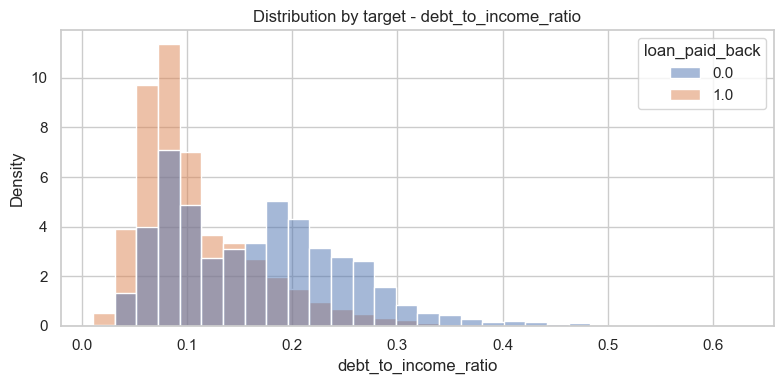

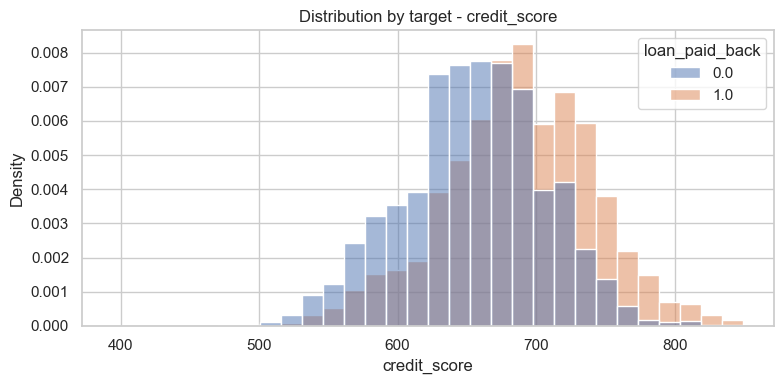

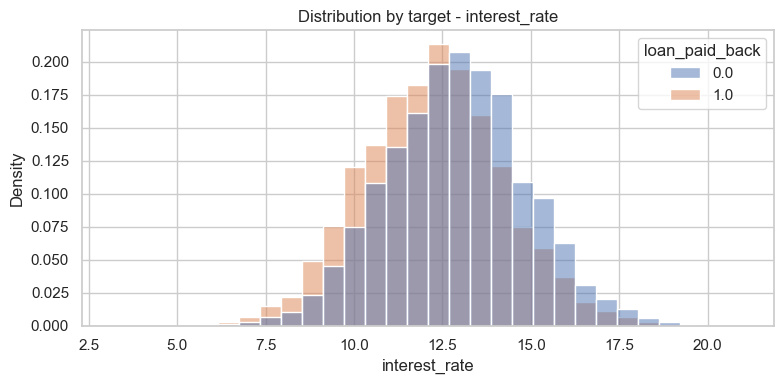

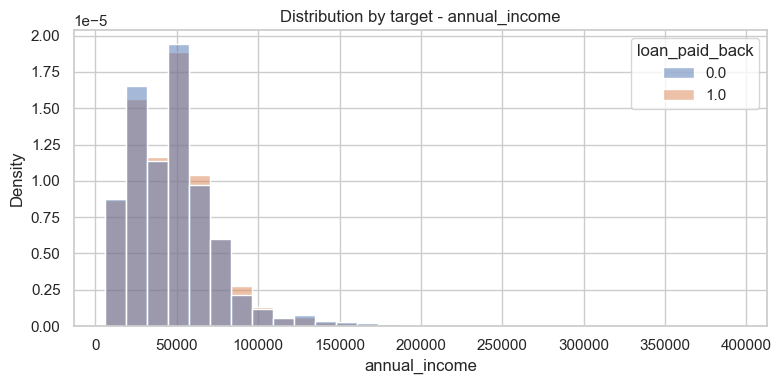

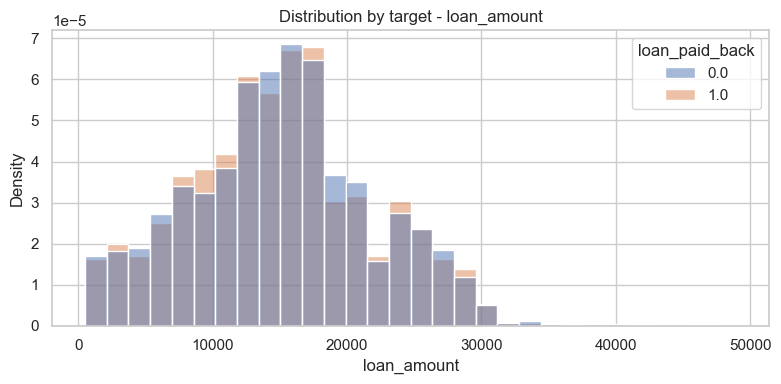

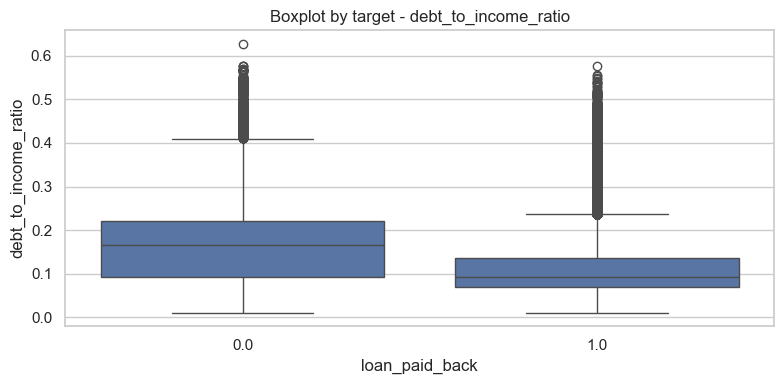

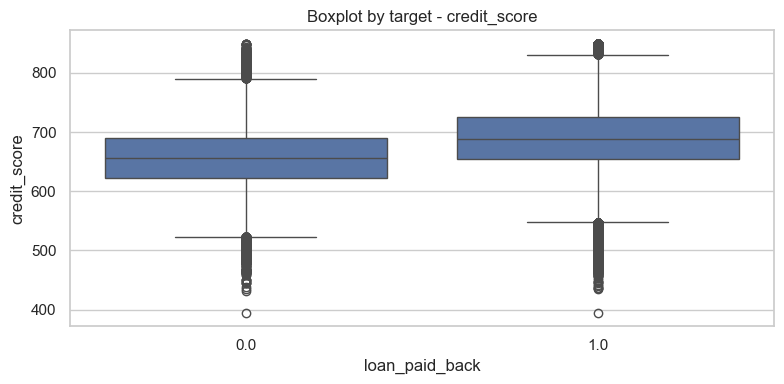

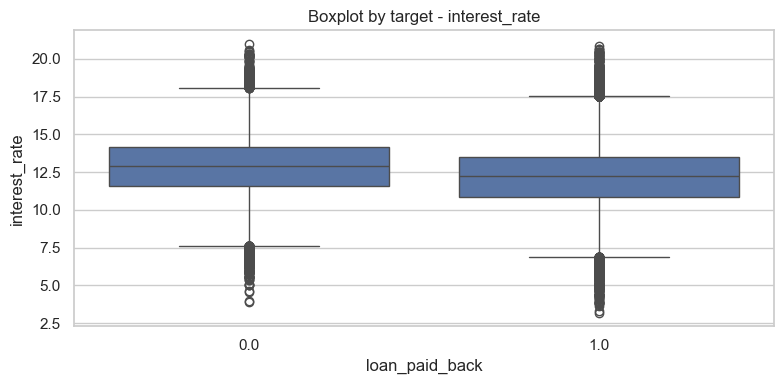

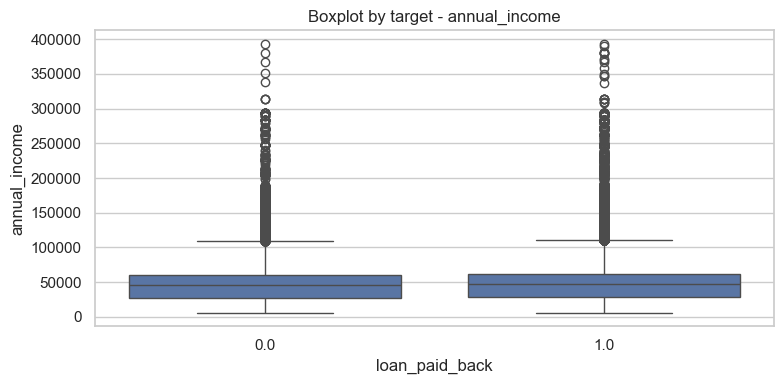

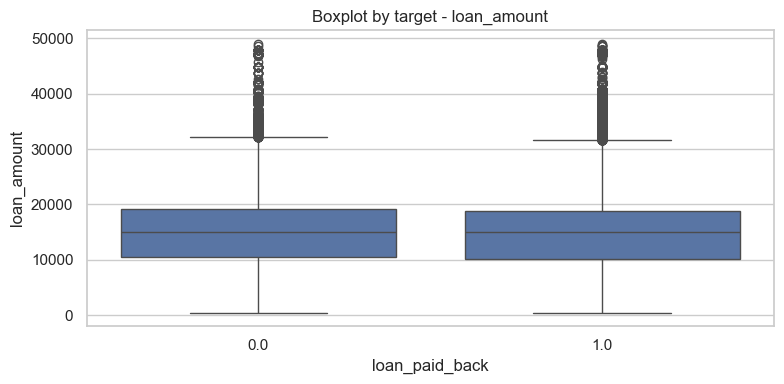

In [12]:
numeric_rows = []

for col in numeric_columns:
    series = train_df[col]
    clean_series = series.dropna()

    if clean_series.empty:
        continue

    q1 = clean_series.quantile(0.25)
    median = clean_series.quantile(0.50)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_rate = ((clean_series < lower_bound) | (clean_series > upper_bound)).mean()

    class_0_mean = train_df.loc[target_numeric == 0, col].mean()
    class_1_mean = train_df.loc[target_numeric == 1, col].mean()
    class_0_median = train_df.loc[target_numeric == 0, col].median()
    class_1_median = train_df.loc[target_numeric == 1, col].median()

    corr_df = pd.DataFrame({col: train_df[col], TARGET_COL: target_numeric}).dropna()
    target_corr = corr_df.corr().iloc[0, 1] if not corr_df.empty else np.nan

    std_value = clean_series.std()
    separation_score = abs(class_1_mean - class_0_mean) / std_value if std_value and not np.isnan(std_value) else np.nan

    numeric_rows.append(
        {
            "column": col,
            "missing_percent": round(series.isna().mean() * 100, 4),
            "mean": clean_series.mean(),
            "median": median,
            "std": std_value,
            "min": clean_series.min(),
            "q1": q1,
            "q3": q3,
            "max": clean_series.max(),
            "skewness": clean_series.skew(),
            "outlier_rate": round(outlier_rate, 4),
            "target_corr": target_corr,
            "abs_target_corr": abs(target_corr) if pd.notna(target_corr) else np.nan,
            "class_0_mean": class_0_mean,
            "class_1_mean": class_1_mean,
            "class_0_median": class_0_median,
            "class_1_median": class_1_median,
            "separation_score": separation_score,
            "needs_log_transform": bool(clean_series.min() >= 0 and abs(clean_series.skew()) > 1.0),
            "needs_outlier_clipping": bool(outlier_rate > 0.05),
        }
    )

numeric_summary = pd.DataFrame(numeric_rows).sort_values(
    ["separation_score", "abs_target_corr"],
    ascending=False
)
display(numeric_summary.head(20))
save_csv(numeric_summary, "numeric_summary.csv")

top_numeric_features = (
    numeric_summary.sort_values(["separation_score", "abs_target_corr"], ascending=False)
    .head(min(TOP_NUMERIC_PLOTS, len(numeric_summary)))["column"]
    .tolist()
)

for col in top_numeric_features:
    plot_df = train_df[[col, TARGET_COL]].dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(data=plot_df, x=col, hue=TARGET_COL, bins=30, stat="density", common_norm=False)
    plt.title(f"Distribution by target - {col}")
    save_plot(f"numeric_hist_by_target_{col}.png")

for col in top_numeric_features:
    plot_df = train_df[[col, TARGET_COL]].dropna()

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=plot_df, x=TARGET_COL, y=col)
    plt.title(f"Boxplot by target - {col}")
    save_plot(f"numeric_boxplot_by_target_{col}.png")

Categorical feature analysis

,column,missing_percent,unique_count_train,unique_count_test,most_frequent_value,most_frequent_value_percent,rare_category_count,rare_category_percent_of_all_categories,train_only_category_count,test_only_category_count,train_only_examples,test_only_examples,target_rate_spread
3,employment_status,0.0,5,5,Employed,75.8669,0,0.0000,0,0,,,0.9196
5,grade_subgrade,0.0,30,30,C3,9.8814,9,30.0000,0,0,,,0.3530
4,loan_purpose,0.0,8,8,Debt consolidation,54.6630,0,0.0000,0,0,,,0.0462
2,education_level,0.0,5,5,Bachelor's,47.0722,0,0.0000,0,0,,,0.0412
1,marital_status,0.0,4,4,Single,48.6273,0,0.0000,0,0,,,0.0093
0,gender,0.0,3,3,Female,51.5451,1,33.3333,0,0,,,0.0064


,column,gender,mean,count,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,gender,Female,0.801708,306175,NaN,NaN,NaN,NaN,NaN
1,gender,Male,0.795752,284091,NaN,NaN,NaN,NaN,NaN
2,gender,Other,0.795333,3728,NaN,NaN,NaN,NaN,NaN
3,marital_status,NaN,0.799144,277239,Married,NaN,NaN,NaN,NaN
4,marital_status,NaN,0.798873,288843,Single,NaN,NaN,NaN,NaN
5,marital_status,NaN,0.796640,21312,Divorced,NaN,NaN,NaN,NaN
6,marital_status,NaN,0.789848,6600,Widowed,NaN,NaN,NaN,NaN
7,education_level,NaN,0.830067,11022,NaN,PhD,NaN,NaN,NaN
8,education_level,NaN,0.809698,183592,NaN,High School,NaN,NaN,NaN
9,education_level,NaN,0.802789,26677,NaN,Other,NaN,NaN,NaN


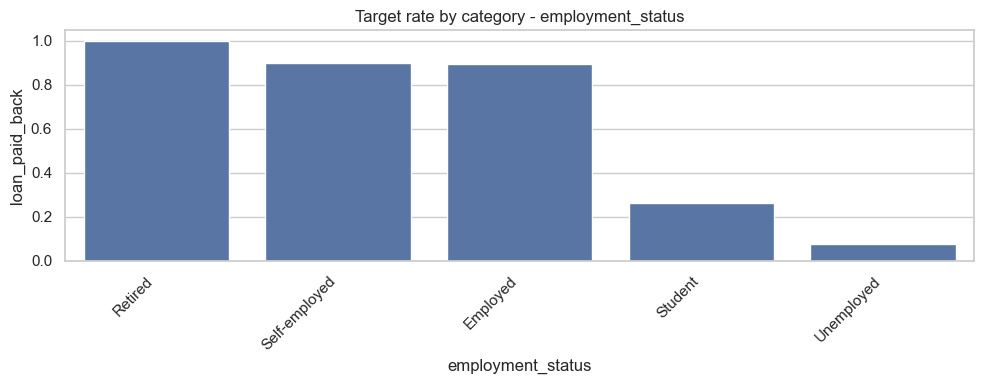

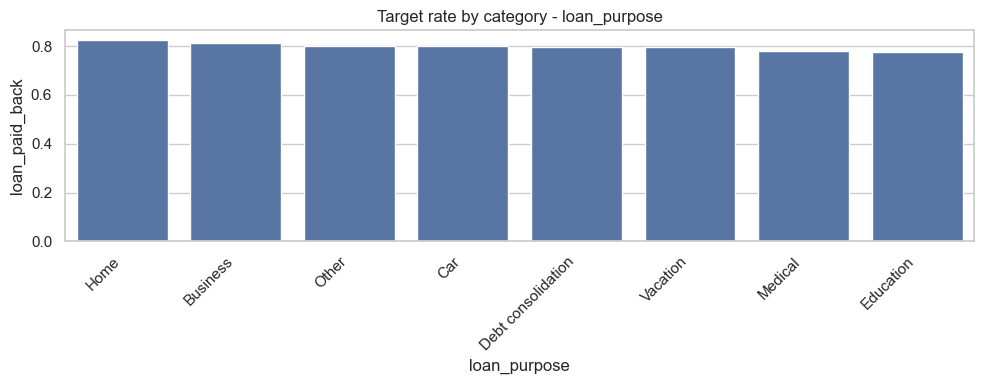

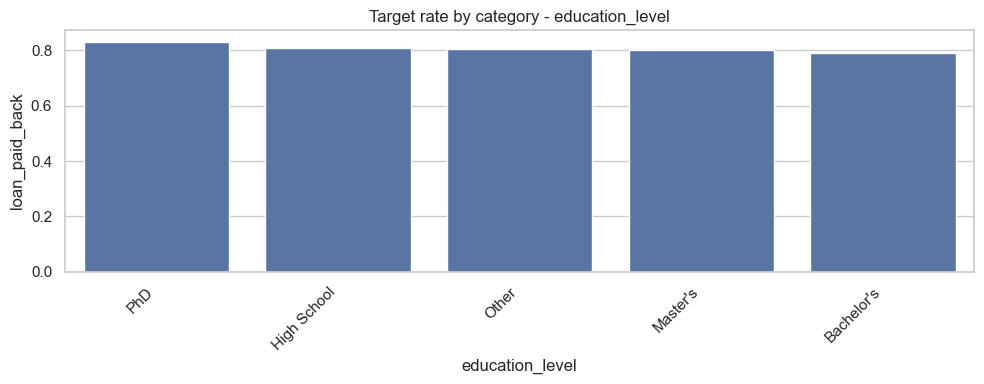

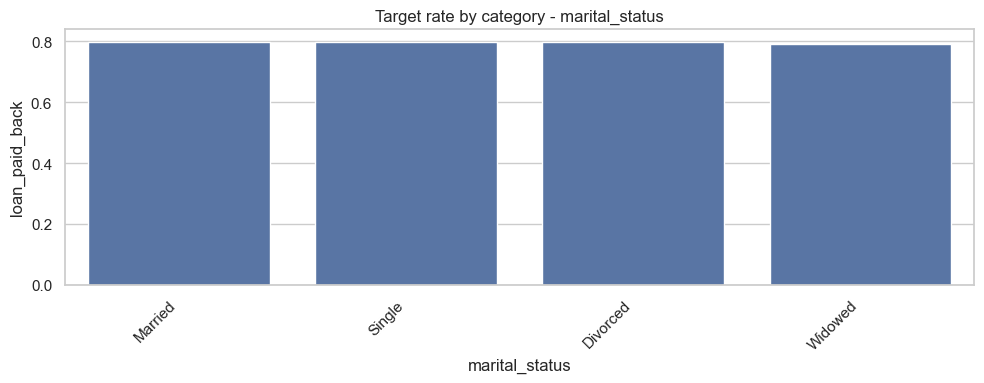

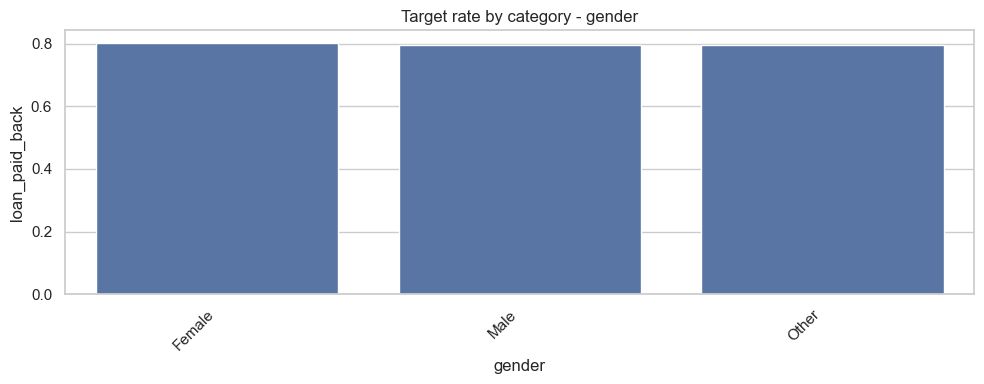

,column,category_value,frequency_ratio
0,gender,Other,0.006276
9,grade_subgrade,A1,0.002694
8,grade_subgrade,A4,0.002864
7,grade_subgrade,A2,0.003397
6,grade_subgrade,A3,0.003478
5,grade_subgrade,A5,0.004160
4,grade_subgrade,F3,0.008556
3,grade_subgrade,F2,0.008759
2,grade_subgrade,F1,0.009317
1,grade_subgrade,F4,0.009318


In [13]:
categorical_rows = []
categorical_target_rate_tables = []

for col in categorical_columns:
    train_series = normalize_categorical(train_df[col])
    test_series = normalize_categorical(test_df[col]) if col in test_df.columns else pd.Series(dtype=str)

    train_value_counts = train_series.value_counts(normalize=True)
    train_unique = train_series.nunique()
    test_unique = test_series.nunique() if not test_series.empty else np.nan

    rare_categories = train_value_counts[train_value_counts < 0.01]
    train_only_categories = sorted(set(train_series.unique()) - set(test_series.unique()))
    test_only_categories = sorted(set(test_series.unique()) - set(train_series.unique()))

    target_rate_table = (
        pd.DataFrame({col: train_series, TARGET_COL: target_numeric})
        .groupby(col)[TARGET_COL]
        .agg(["mean", "count"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )

    target_rate_table.insert(0, "column", col)
    categorical_target_rate_tables.append(target_rate_table)

    target_rate_spread = target_rate_table["mean"].max() - target_rate_table["mean"].min() if not target_rate_table.empty else np.nan

    categorical_rows.append(
        {
            "column": col,
            "missing_percent": round(train_df[col].isna().mean() * 100, 4),
            "unique_count_train": train_unique,
            "unique_count_test": test_unique,
            "most_frequent_value": train_series.mode().iloc[0] if not train_series.mode().empty else np.nan,
            "most_frequent_value_percent": round(train_value_counts.iloc[0] * 100, 4) if not train_value_counts.empty else np.nan,
            "rare_category_count": int(len(rare_categories)),
            "rare_category_percent_of_all_categories": round((len(rare_categories) / train_unique) * 100, 4) if train_unique > 0 else np.nan,
            "train_only_category_count": len(train_only_categories),
            "test_only_category_count": len(test_only_categories),
            "train_only_examples": " | ".join(train_only_categories[:5]),
            "test_only_examples": " | ".join(test_only_categories[:5]),
            "target_rate_spread": round(target_rate_spread, 4) if pd.notna(target_rate_spread) else np.nan,
        }
    )

categorical_summary = pd.DataFrame(categorical_rows).sort_values(
    ["target_rate_spread", "unique_count_train"],
    ascending=[False, False]
)
display(categorical_summary.head(20))
save_csv(categorical_summary, "categorical_summary.csv")

categorical_target_rates = (
    pd.concat(categorical_target_rate_tables, ignore_index=True)
    if categorical_target_rate_tables
    else pd.DataFrame(columns=["column", "category", "mean", "count"])
)
display(categorical_target_rates.head(20))
save_csv(categorical_target_rates, "categorical_target_rates.csv")

plot_candidate_columns = (
    categorical_summary[categorical_summary["unique_count_train"] <= 15]
    .sort_values("target_rate_spread", ascending=False)
    .head(TOP_CATEGORICAL_PLOTS)["column"]
    .tolist()
)

for col in plot_candidate_columns:
    plot_df = (
        pd.DataFrame({
            col: normalize_categorical(train_df[col]),
            TARGET_COL: target_numeric
        })
        .groupby(col)[TARGET_COL]
        .mean()
        .reset_index()
        .sort_values(TARGET_COL, ascending=False)
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=plot_df, x=col, y=TARGET_COL)
    plt.title(f"Target rate by category - {col}")
    plt.xticks(rotation=45, ha="right")
    save_plot(f"categorical_target_rate_{col}.png")

rare_category_rows = []

for col in categorical_columns:
    series = normalize_categorical(train_df[col])
    value_counts = series.value_counts(normalize=True)

    rare_values = value_counts[value_counts < 0.01]

    for category_value, ratio in rare_values.items():
        rare_category_rows.append(
            {
                "column": col,
                "category_value": category_value,
                "frequency_ratio": round(ratio, 6),
            }
        )

rare_category_table = pd.DataFrame(
    rare_category_rows,
    columns=["column", "category_value", "frequency_ratio"]
).sort_values(["column", "frequency_ratio"], ascending=[True, True])

display(rare_category_table.head(30))
save_csv(rare_category_table, "rare_category_table.csv")

Train vs test comparison

In [14]:
numeric_shift_rows = []

for col in numeric_columns:
    train_series = train_df[col].dropna()
    test_series = test_df[col].dropna()

    if train_series.empty or test_series.empty:
        continue

    ks_stat, ks_pvalue = ks_2samp(train_series, test_series)

    train_mean = train_series.mean()
    test_mean = test_series.mean()
    train_std = train_series.std()

    mean_diff_std = abs(train_mean - test_mean) / train_std if train_std and not np.isnan(train_std) else np.nan
    missing_gap = train_df[col].isna().mean() - test_df[col].isna().mean()

    if ks_stat >= 0.20:
        shift_label = "strongly shifted"
    elif ks_stat >= 0.10:
        shift_label = "slightly shifted"
    else:
        shift_label = "stable"

    numeric_shift_rows.append(
        {
            "column": col,
            "feature_type": "numeric",
            "train_mean": train_mean,
            "test_mean": test_mean,
            "train_min": train_series.min(),
            "test_min": test_series.min(),
            "train_max": train_series.max(),
            "test_max": test_series.max(),
            "missing_rate_gap": round(missing_gap * 100, 4),
            "ks_statistic": round(ks_stat, 4),
            "ks_pvalue": ks_pvalue,
            "mean_diff_std": round(mean_diff_std, 4) if pd.notna(mean_diff_std) else np.nan,
            "shift_label": shift_label,
        }
    )

numeric_shift_summary = pd.DataFrame(numeric_shift_rows).sort_values("ks_statistic", ascending=False)
display(numeric_shift_summary.head(20))
save_csv(numeric_shift_summary, "numeric_shift_summary.csv")

categorical_shift_rows = []

for col in categorical_columns:
    train_series = normalize_categorical(train_df[col])
    test_series = normalize_categorical(test_df[col])

    train_freq = train_series.value_counts(normalize=True)
    test_freq = test_series.value_counts(normalize=True)

    all_categories = sorted(set(train_freq.index) | set(test_freq.index))

    train_freq_aligned = train_freq.reindex(all_categories, fill_value=0)
    test_freq_aligned = test_freq.reindex(all_categories, fill_value=0)

    tvd = 0.5 * np.abs(train_freq_aligned - test_freq_aligned).sum()

    train_only = sorted(set(train_series.unique()) - set(test_series.unique()))
    test_only = sorted(set(test_series.unique()) - set(train_series.unique()))

    if tvd >= 0.30 or len(test_only) > 0:
        shift_label = "strongly shifted"
    elif tvd >= 0.10:
        shift_label = "slightly shifted"
    else:
        shift_label = "stable"

    categorical_shift_rows.append(
        {
            "column": col,
            "feature_type": "categorical",
            "missing_rate_gap": round((train_df[col].isna().mean() - test_df[col].isna().mean()) * 100, 4),
            "train_unique_count": train_series.nunique(),
            "test_unique_count": test_series.nunique(),
            "train_only_category_count": len(train_only),
            "test_only_category_count": len(test_only),
            "train_only_examples": " | ".join(train_only[:5]),
            "test_only_examples": " | ".join(test_only[:5]),
            "tvd": round(tvd, 4),
            "shift_label": shift_label,
        }
    )

categorical_shift_summary = pd.DataFrame(categorical_shift_rows).sort_values(
    ["tvd", "test_only_category_count"],
    ascending=False
)
display(categorical_shift_summary.head(20))
save_csv(categorical_shift_summary, "categorical_shift_summary.csv")

train_test_shift_summary = pd.concat(
    [numeric_shift_summary, categorical_shift_summary],
    ignore_index=True,
    sort=False
).sort_values(["shift_label", "column"], ascending=[True, True])

display(train_test_shift_summary.head(30))
save_csv(train_test_shift_summary, "train_test_shift_summary.csv")

stable_columns = train_test_shift_summary[train_test_shift_summary["shift_label"] == "stable"]["column"].tolist()
slightly_shifted_columns = train_test_shift_summary[train_test_shift_summary["shift_label"] == "slightly shifted"]["column"].tolist()
strongly_shifted_columns = train_test_shift_summary[train_test_shift_summary["shift_label"] == "strongly shifted"]["column"].tolist()

shift_groups = {
    "stable_columns": stable_columns,
    "slightly_shifted_columns": slightly_shifted_columns,
    "strongly_shifted_columns": strongly_shifted_columns,
}
write_text("shift_groups.json", json.dumps(shift_groups, indent=2, ensure_ascii=False))
shift_groups

,column,feature_type,train_mean,test_mean,train_min,test_min,train_max,test_max,missing_rate_gap,ks_statistic,ks_pvalue,mean_diff_std,shift_label
4,interest_rate,numeric,12.356345,12.352323,3.200,3.200,20.990,21.290,0.0,0.0026,0.180726,0.0020,stable
1,debt_to_income_ratio,numeric,0.120696,0.120583,0.011,0.011,0.627,0.627,0.0,0.0021,0.433605,0.0016,stable
0,annual_income,numeric,48212.202976,48233.080193,6002.430,6011.770,393381.740,380653.940,0.0,0.0019,0.538988,0.0008,stable
2,credit_score,numeric,680.916009,681.037691,395.000,395.000,849.000,849.000,0.0,0.0019,0.555979,0.0022,stable
3,loan_amount,numeric,15020.297629,15016.753484,500.090,500.050,48959.950,48959.260,0.0,0.0017,0.678600,0.0005,stable


,column,feature_type,missing_rate_gap,train_unique_count,test_unique_count,train_only_category_count,test_only_category_count,train_only_examples,test_only_examples,tvd,shift_label
5,grade_subgrade,categorical,0.0,30,30,0,0,,,0.0039,stable
4,loan_purpose,categorical,0.0,8,8,0,0,,,0.0017,stable
0,gender,categorical,0.0,3,3,0,0,,,0.0012,stable
1,marital_status,categorical,0.0,4,4,0,0,,,0.0007,stable
2,education_level,categorical,0.0,5,5,0,0,,,0.0007,stable
3,employment_status,categorical,0.0,5,5,0,0,,,0.0005,stable


,column,feature_type,train_mean,test_mean,train_min,test_min,train_max,test_max,missing_rate_gap,ks_statistic,ks_pvalue,mean_diff_std,shift_label,train_unique_count,test_unique_count,train_only_category_count,test_only_category_count,train_only_examples,test_only_examples,tvd
2,annual_income,numeric,48212.202976,48233.080193,6002.430,6011.770,393381.740,380653.940,0.0,0.0019,0.538988,0.0008,stable,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,credit_score,numeric,680.916009,681.037691,395.000,395.000,849.000,849.000,0.0,0.0019,0.555979,0.0022,stable,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,debt_to_income_ratio,numeric,0.120696,0.120583,0.011,0.011,0.627,0.627,0.0,0.0021,0.433605,0.0016,stable,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,education_level,categorical,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,stable,5.0,5.0,0.0,0.0,,,0.0007
10,employment_status,categorical,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,stable,5.0,5.0,0.0,0.0,,,0.0005
7,gender,categorical,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,stable,3.0,3.0,0.0,0.0,,,0.0012
5,grade_subgrade,categorical,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,stable,30.0,30.0,0.0,0.0,,,0.0039
0,interest_rate,numeric,12.356345,12.352323,3.200,3.200,20.990,21.290,0.0,0.0026,0.180726,0.0020,stable,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,loan_amount,numeric,15020.297629,15016.753484,500.090,500.050,48959.950,48959.260,0.0,0.0017,0.678600,0.0005,stable,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,loan_purpose,categorical,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,stable,8.0,8.0,0.0,0.0,,,0.0017


{'stable_columns': ['annual_income',
  'credit_score',
  'debt_to_income_ratio',
  'education_level',
  'employment_status',
  'gender',
  'grade_subgrade',
  'interest_rate',
  'loan_amount',
  'loan_purpose',
  'marital_status'],
 'slightly_shifted_columns': [],
 'strongly_shifted_columns': []}

Leakage and risk check

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
annual_income,1.000000,0.000553,0.001509,-0.003407,-0.002507,0.006326
debt_to_income_ratio,0.000553,1.000000,-0.061617,-0.008236,0.030316,-0.335680
credit_score,0.001509,-0.061617,1.000000,-0.005761,-0.538335,0.234560
loan_amount,-0.003407,-0.008236,-0.005761,1.000000,-0.001174,-0.003762
interest_rate,-0.002507,0.030316,-0.538335,-0.001174,1.000000,-0.131184


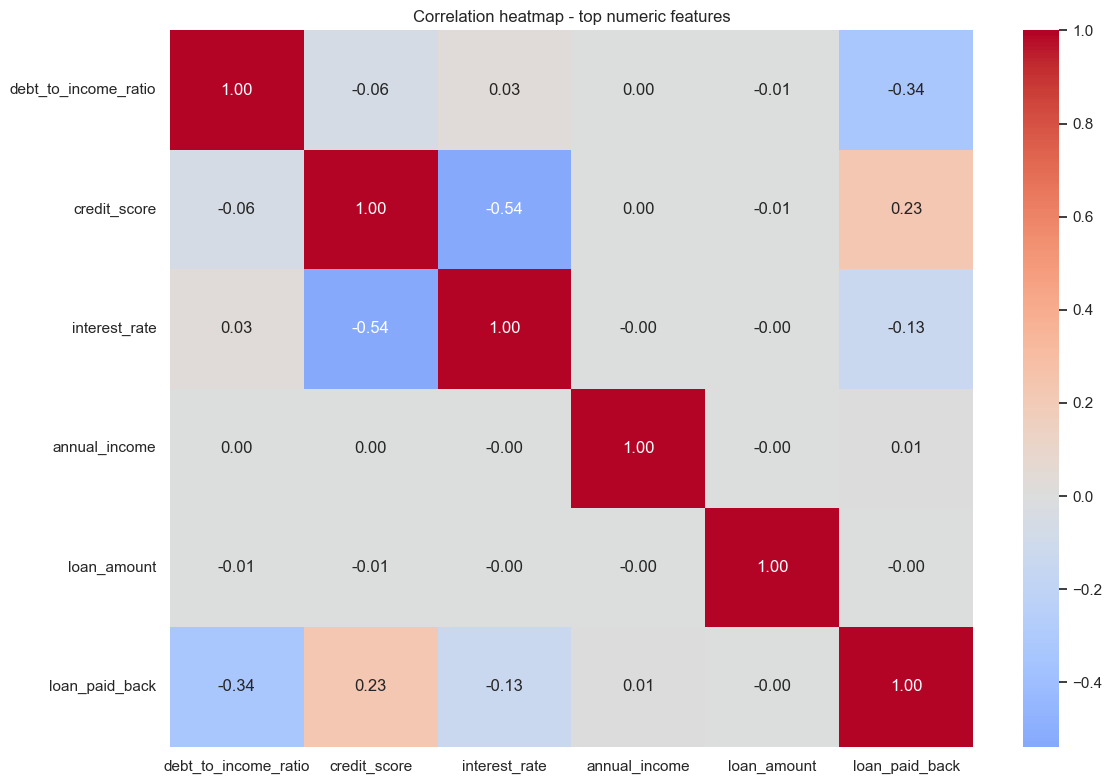

,feature_a,feature_b,correlation,abs_correlation


,column,target_correlation,abs_target_correlation
1,debt_to_income_ratio,-0.335680,0.335680
2,credit_score,0.234560,0.234560
4,interest_rate,-0.131184,0.131184
0,annual_income,0.006326,0.006326
3,loan_amount,-0.003762,0.003762


,column,leakage_name_flag
7,marital_status,True
9,employment_status,True
12,loan_paid_back,True


,column,missing_percent,mean,median,std,min,q1,q3,max,skewness,outlier_rate,target_corr,abs_target_corr,class_0_mean,class_1_mean,class_0_median,class_1_median,separation_score,needs_log_transform,needs_outlier_clipping,reason


,column,suspicious_category_count,example_categories,reason
0,employment_status,1,Retired,Category with near-perfect target rate


,column,why_suspicious,action
1,employment_status,Column name suggests post-outcome information | Categorical feature contains near-perfect target groups,review
2,loan_paid_back,Column name suggests post-outcome information | Target column itself,remove
0,marital_status,Column name suggests post-outcome information,review


In [15]:
numeric_for_corr = [col for col in numeric_columns if train_df[col].nunique(dropna=True) > 1]

if numeric_for_corr:
    corr_input = train_df[numeric_for_corr].copy()
    corr_input[TARGET_COL] = target_numeric

    corr_matrix = corr_input.corr(numeric_only=True)
    corr_matrix.to_csv(TABLES_DIR / "correlation_matrix.csv", encoding="utf-8")
    display(corr_matrix.head())

    corr_without_target = corr_matrix.drop(index=TARGET_COL, columns=[TARGET_COL], errors="ignore")

    high_corr_pairs = (
        corr_without_target.where(np.triu(np.ones(corr_without_target.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    high_corr_pairs.columns = ["feature_a", "feature_b", "correlation"]
    high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
    high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.85].sort_values(
        "abs_correlation", ascending=False
    )

    target_correlations = (
        corr_matrix[TARGET_COL]
        .drop(TARGET_COL, errors="ignore")
        .reset_index()
    )
    target_correlations.columns = ["column", "target_correlation"]
    target_correlations["abs_target_correlation"] = target_correlations["target_correlation"].abs()
    target_correlations = target_correlations.sort_values("abs_target_correlation", ascending=False)

    top_corr_columns = target_correlations.head(min(15, len(target_correlations)))["column"].tolist()
    heatmap_columns = top_corr_columns + [TARGET_COL]

    plt.figure(figsize=(12, 8))
    sns.heatmap(train_df[heatmap_columns].assign(**{TARGET_COL: target_numeric}).corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation heatmap - top numeric features")
    save_plot("correlation_heatmap_top_features.png")
else:
    corr_matrix = pd.DataFrame()
    high_corr_pairs = pd.DataFrame(columns=["feature_a", "feature_b", "correlation", "abs_correlation"])
    target_correlations = pd.DataFrame(columns=["column", "target_correlation", "abs_target_correlation"])

display(high_corr_pairs.head(20))
display(target_correlations.head(20))

save_csv(high_corr_pairs, "high_correlation_pairs.csv")
save_csv(target_correlations, "target_correlations_numeric.csv")

name_based_leakage = pd.DataFrame(
    {
        "column": train_df.columns,
        "leakage_name_flag": [leakage_name_flag(col) for col in train_df.columns],
    }
)
name_based_leakage = name_based_leakage[name_based_leakage["leakage_name_flag"]].copy()
display(name_based_leakage)
save_csv(name_based_leakage, "name_based_leakage_flags.csv")

if not numeric_summary.empty:
    numeric_leakage_candidates = numeric_summary[
        (numeric_summary["abs_target_corr"] >= 0.95) |
        (numeric_summary["separation_score"] >= 3.0)
    ].copy()
    numeric_leakage_candidates["reason"] = "Very strong numeric relationship with target"
else:
    numeric_leakage_candidates = pd.DataFrame(columns=list(numeric_summary.columns) + ["reason"])

display(numeric_leakage_candidates)
save_csv(numeric_leakage_candidates, "numeric_leakage_candidates.csv")

categorical_leakage_rows = []

for col in categorical_columns:
    tmp = (
        pd.DataFrame({
            col: normalize_categorical(train_df[col]),
            TARGET_COL: target_numeric
        })
        .groupby(col)[TARGET_COL]
        .agg(["mean", "count"])
        .reset_index()
    )

    suspicious_categories = tmp[(tmp["count"] >= 20) & ((tmp["mean"] <= 0.01) | (tmp["mean"] >= 0.99))]

    if not suspicious_categories.empty:
        categorical_leakage_rows.append(
            {
                "column": col,
                "suspicious_category_count": len(suspicious_categories),
                "example_categories": " | ".join(suspicious_categories[col].astype(str).head(5).tolist()),
                "reason": "Category with near-perfect target rate",
            }
        )

categorical_leakage_candidates = pd.DataFrame(
    categorical_leakage_rows,
    columns=["column", "suspicious_category_count", "example_categories", "reason"]
)
display(categorical_leakage_candidates)
save_csv(categorical_leakage_candidates, "categorical_leakage_candidates.csv")

leakage_review_rows = []

for col in train_df.columns:
    reasons = []

    if leakage_name_flag(col):
        reasons.append("Column name suggests post-outcome information")

    if col in numeric_leakage_candidates["column"].tolist():
        reasons.append("Numeric feature is suspiciously predictive")

    if col in categorical_leakage_candidates["column"].tolist():
        reasons.append("Categorical feature contains near-perfect target groups")

    if col == TARGET_COL:
        reasons.append("Target column itself")

    if reasons:
        leakage_review_rows.append(
            {
                "column": col,
                "why_suspicious": " | ".join(reasons),
                "action": "review" if col != TARGET_COL else "remove",
            }
        )

leakage_review = pd.DataFrame(
    leakage_review_rows,
    columns=["column", "why_suspicious", "action"]
).sort_values("column")

display(leakage_review)
save_csv(leakage_review, "leakage_review.csv")

Preliminary preprocessing recommendations

In [16]:
if not numeric_summary.empty:
    numeric_usefulness = numeric_summary.merge(
        train_test_shift_summary[["column", "shift_label"]],
        on="column",
        how="left"
    )

    numeric_usefulness["feature_type"] = "numeric"
    numeric_usefulness["signal_score"] = (
        numeric_usefulness["abs_target_corr"].fillna(0) +
        numeric_usefulness["separation_score"].fillna(0).clip(upper=5) / 5
    )

    numeric_usefulness["likely_usefulness"] = np.select(
        [
            numeric_usefulness["column"].isin(leakage_review["column"]),
            numeric_usefulness["signal_score"] >= 0.60,
            numeric_usefulness["signal_score"] >= 0.25,
        ],
        [
            "low",
            "high",
            "medium",
        ],
        default="low"
    )

    numeric_usefulness["recommended_preprocessing"] = np.select(
        [
            numeric_usefulness["column"].isin(leakage_review["column"]),
            numeric_usefulness["needs_log_transform"] & numeric_usefulness["needs_outlier_clipping"],
            numeric_usefulness["needs_log_transform"],
            numeric_usefulness["needs_outlier_clipping"],
        ],
        [
            "review/remove",
            "median impute + log transform + clip outliers",
            "median impute + log transform",
            "median impute + clip outliers",
        ],
        default="median impute"
    )

    numeric_usefulness["why"] = (
        "abs_target_corr=" + numeric_usefulness["abs_target_corr"].round(4).astype(str) +
        ", separation_score=" + numeric_usefulness["separation_score"].round(4).astype(str) +
        ", shift=" + numeric_usefulness["shift_label"].fillna("unknown").astype(str)
    )

    numeric_usefulness = numeric_usefulness[
        ["column", "feature_type", "likely_usefulness", "recommended_preprocessing", "why"]
    ]
else:
    numeric_usefulness = pd.DataFrame(columns=["column", "feature_type", "likely_usefulness", "recommended_preprocessing", "why"])

if not categorical_summary.empty:
    categorical_usefulness = categorical_summary.merge(
        train_test_shift_summary[["column", "shift_label"]],
        on="column",
        how="left"
    )

    categorical_usefulness["feature_type"] = "categorical"
    categorical_usefulness["likely_usefulness"] = np.select(
        [
            categorical_usefulness["column"].isin(leakage_review["column"]),
            categorical_usefulness["target_rate_spread"] >= 0.30,
            categorical_usefulness["target_rate_spread"] >= 0.10,
        ],
        [
            "low",
            "high",
            "medium",
        ],
        default="low"
    )

    categorical_usefulness["recommended_preprocessing"] = np.select(
        [
            categorical_usefulness["column"].isin(leakage_review["column"]),
            categorical_usefulness["unique_count_train"] > HIGH_CARDINALITY_THRESHOLD,
            categorical_usefulness["unique_count_train"] > 10,
        ],
        [
            "review/remove",
            "impute Missing + frequency or target encoding",
            "impute Missing + one-hot or frequency encoding",
        ],
        default="impute Missing + one-hot"
    )

    categorical_usefulness["why"] = (
        "target_rate_spread=" + categorical_usefulness["target_rate_spread"].round(4).astype(str) +
        ", unique_count=" + categorical_usefulness["unique_count_train"].astype(str) +
        ", shift=" + categorical_usefulness["shift_label"].fillna("unknown").astype(str)
    )

    categorical_usefulness = categorical_usefulness[
        ["column", "feature_type", "likely_usefulness", "recommended_preprocessing", "why"]
    ]
else:
    categorical_usefulness = pd.DataFrame(columns=["column", "feature_type", "likely_usefulness", "recommended_preprocessing", "why"])

feature_recommendations = pd.concat(
    [numeric_usefulness, categorical_usefulness],
    ignore_index=True
).sort_values(["likely_usefulness", "feature_type", "column"], ascending=[True, True, True])

display(feature_recommendations.head(30))
save_csv(feature_recommendations, "feature_recommendations.csv")

constant_columns = constant_summary[constant_summary["is_constant"]]["column"].tolist()
near_constant_columns = constant_summary[constant_summary["is_near_constant_98pct"]]["column"].tolist()
leakage_columns = leakage_review["column"].tolist()

drop_columns = sorted(set(id_columns + constant_columns + leakage_columns))
review_columns = sorted(set(near_constant_columns) - set(drop_columns))

numeric_impute_columns = [col for col in numeric_columns if col not in drop_columns]
categorical_impute_columns = [col for col in categorical_columns if col not in drop_columns]

one_hot_columns = categorical_summary[
    (categorical_summary["unique_count_train"] <= 10) &
    (~categorical_summary["column"].isin(drop_columns))
]["column"].tolist()

frequency_encode_columns = categorical_summary[
    (categorical_summary["unique_count_train"] > 10) &
    (~categorical_summary["column"].isin(drop_columns))
]["column"].tolist()

log_transform_columns = numeric_summary[
    (numeric_summary["needs_log_transform"]) &
    (~numeric_summary["column"].isin(drop_columns))
]["column"].tolist()

clip_outlier_columns = numeric_summary[
    (numeric_summary["needs_outlier_clipping"]) &
    (~numeric_summary["column"].isin(drop_columns))
]["column"].tolist()

preprocessing_plan = pd.DataFrame(
    {
        "step": [
            "drop_columns",
            "review_columns",
            "drop_duplicate_rows",
            "numeric_imputation",
            "categorical_imputation",
            "one_hot_encoding",
            "frequency_or_target_encoding",
            "log_transform",
            "clip_outliers",
            "validation",
        ],
        "recommendation": [
            pretty_join(drop_columns, limit=100),
            pretty_join(review_columns, limit=100),
            f"train duplicate rows: {train_df.duplicated().sum()}, test duplicate rows: {test_df.duplicated().sum()}",
            pretty_join(numeric_impute_columns, limit=100),
            pretty_join(categorical_impute_columns, limit=100),
            pretty_join(one_hot_columns, limit=100),
            pretty_join(frequency_encode_columns, limit=100),
            pretty_join(log_transform_columns, limit=100),
            pretty_join(clip_outlier_columns, limit=100),
            "Use stratified split or stratified k-fold. Keep preprocessing identical for train and test. Handle unseen categories safely.",
        ],
    }
)
display(preprocessing_plan)
save_csv(preprocessing_plan, "preprocessing_plan.csv")

preprocessing_text = f"""
# Preprocessing recommendations

## Drop
- {pretty_join(drop_columns, limit=100)}

## Review
- {pretty_join(review_columns, limit=100)}

## Numeric imputation
- Use median imputation for: {pretty_join(numeric_impute_columns, limit=100)}

## Categorical imputation
- Use 'Missing' for: {pretty_join(categorical_impute_columns, limit=100)}

## Encoding
- One-hot encode: {pretty_join(one_hot_columns, limit=100)}
- Frequency or target encode: {pretty_join(frequency_encode_columns, limit=100)}

## Transform
- Log transform: {pretty_join(log_transform_columns, limit=100)}
- Clip outliers: {pretty_join(clip_outlier_columns, limit=100)}

## Validation
- Use stratified split or stratified k-fold
- Keep preprocessing identical for train and test
- Handle unseen categories safely
"""
write_text("preprocessing_recommendations.md", preprocessing_text)
print(preprocessing_text)

,column,feature_type,likely_usefulness,recommended_preprocessing,why
6,grade_subgrade,categorical,high,impute Missing + one-hot or frequency encoding,"target_rate_spread=0.353, unique_count=30, shift=stable"
8,education_level,categorical,low,impute Missing + one-hot,"target_rate_spread=0.0412, unique_count=5, shift=stable"
5,employment_status,categorical,low,review/remove,"target_rate_spread=0.9196, unique_count=5, shift=stable"
10,gender,categorical,low,impute Missing + one-hot,"target_rate_spread=0.0064, unique_count=3, shift=stable"
7,loan_purpose,categorical,low,impute Missing + one-hot,"target_rate_spread=0.0462, unique_count=8, shift=stable"
9,marital_status,categorical,low,review/remove,"target_rate_spread=0.0093, unique_count=4, shift=stable"
3,annual_income,numeric,low,median impute + log transform,"abs_target_corr=0.0063, separation_score=0.0158, shift=stable"
2,interest_rate,numeric,low,median impute,"abs_target_corr=0.1312, separation_score=0.3272, shift=stable"
4,loan_amount,numeric,low,median impute,"abs_target_corr=0.0038, separation_score=0.0094, shift=stable"
1,credit_score,numeric,medium,median impute,"abs_target_corr=0.2346, separation_score=0.5851, shift=stable"


,step,recommendation
0,drop_columns,"employment_status, id, loan_paid_back, marital_status"
1,review_columns,None
2,drop_duplicate_rows,"train duplicate rows: 0, test duplicate rows: 0"
3,numeric_imputation,"annual_income, debt_to_income_ratio, credit_score, loan_amount, interest_rate"
4,categorical_imputation,"gender, education_level, loan_purpose, grade_subgrade"
5,one_hot_encoding,"loan_purpose, education_level, gender"
6,frequency_or_target_encoding,grade_subgrade
7,log_transform,"debt_to_income_ratio, annual_income"
8,clip_outliers,None
9,validation,Use stratified split or stratified k-fold. Keep preprocessing identical for train and test. Handle unseen categories...



# Preprocessing recommendations

## Drop
- employment_status, id, loan_paid_back, marital_status

## Review
- None

## Numeric imputation
- Use median imputation for: annual_income, debt_to_income_ratio, credit_score, loan_amount, interest_rate

## Categorical imputation
- Use 'Missing' for: gender, education_level, loan_purpose, grade_subgrade

## Encoding
- One-hot encode: loan_purpose, education_level, gender
- Frequency or target encode: grade_subgrade

## Transform
- Log transform: debt_to_income_ratio, annual_income
- Clip outliers: None

## Validation
- Use stratified split or stratified k-fold
- Keep preprocessing identical for train and test
- Handle unseen categories safely



Final conclusions for developer

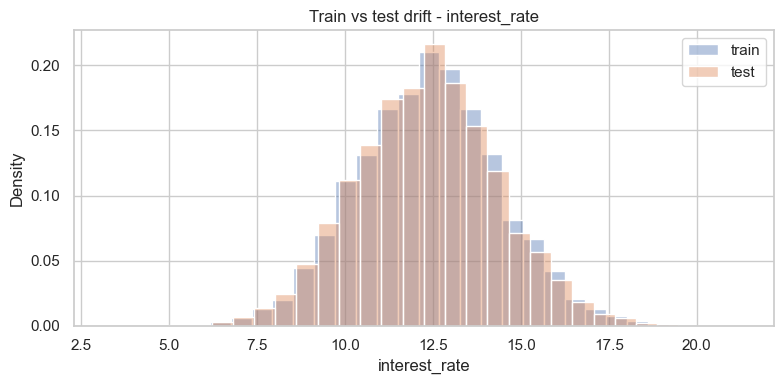

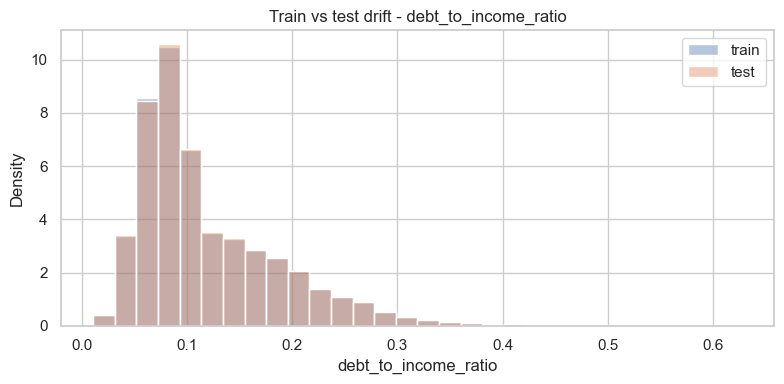

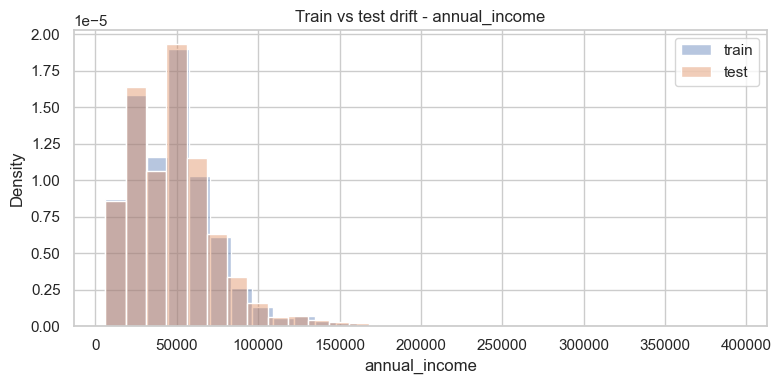

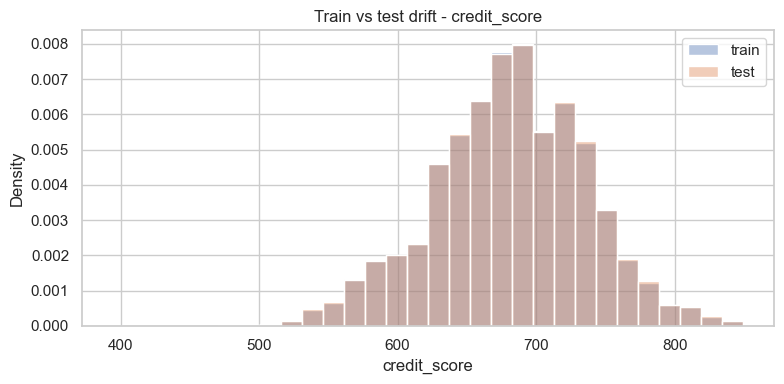

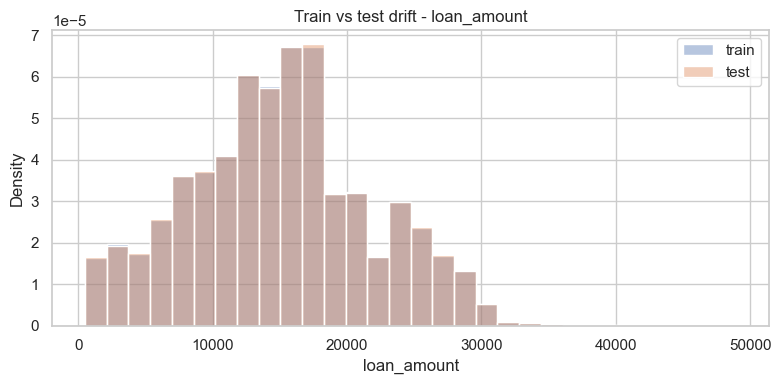

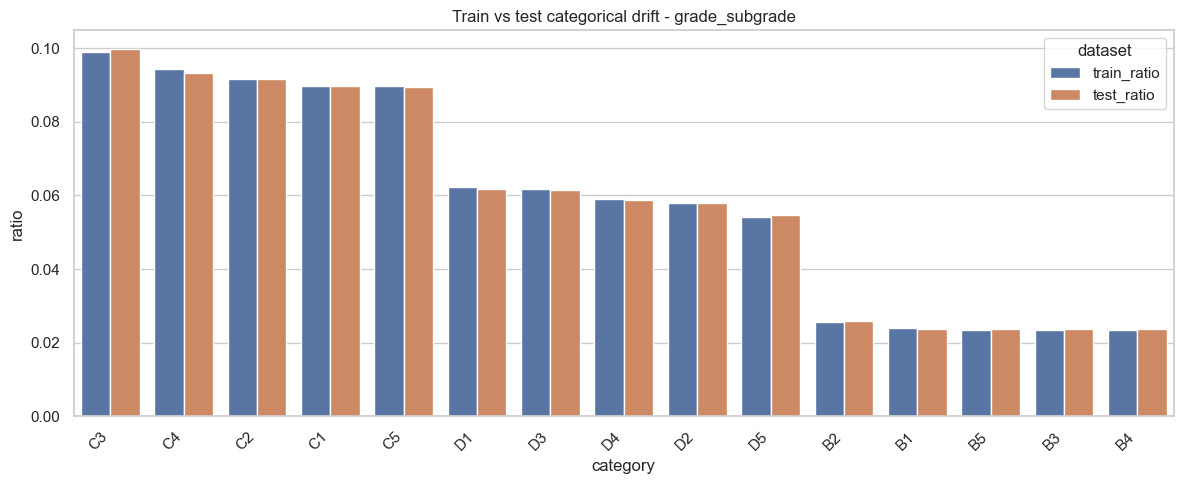

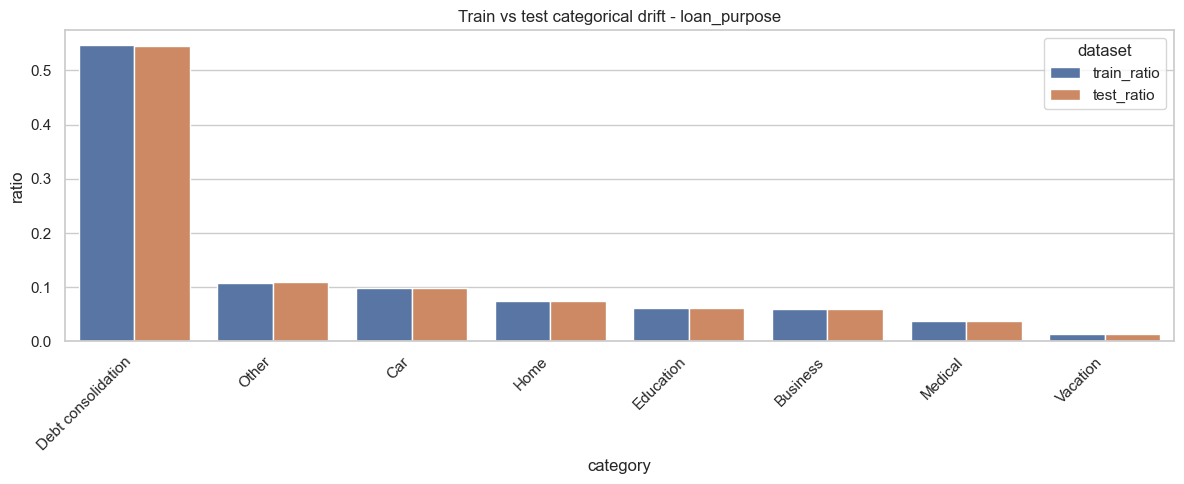

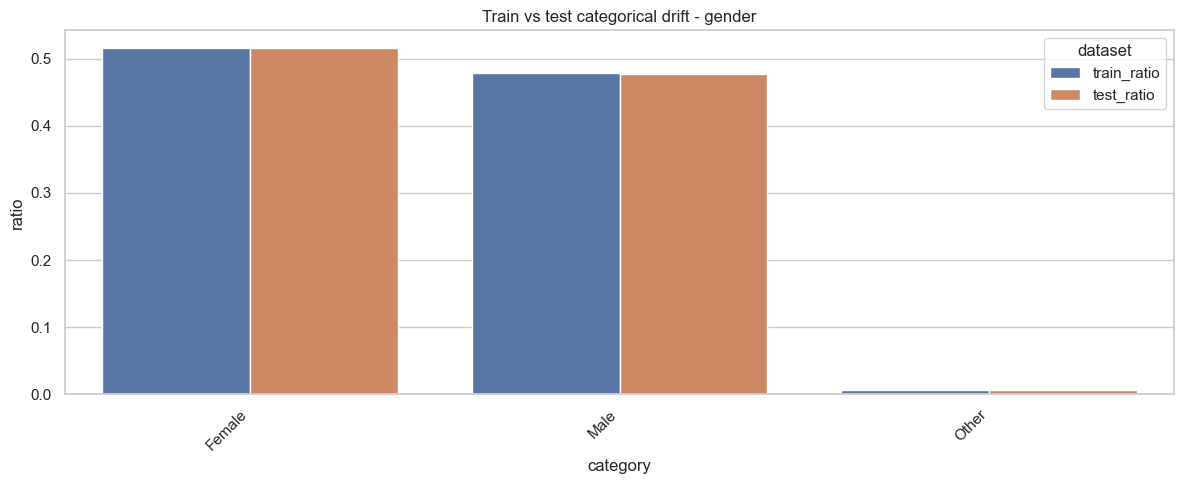

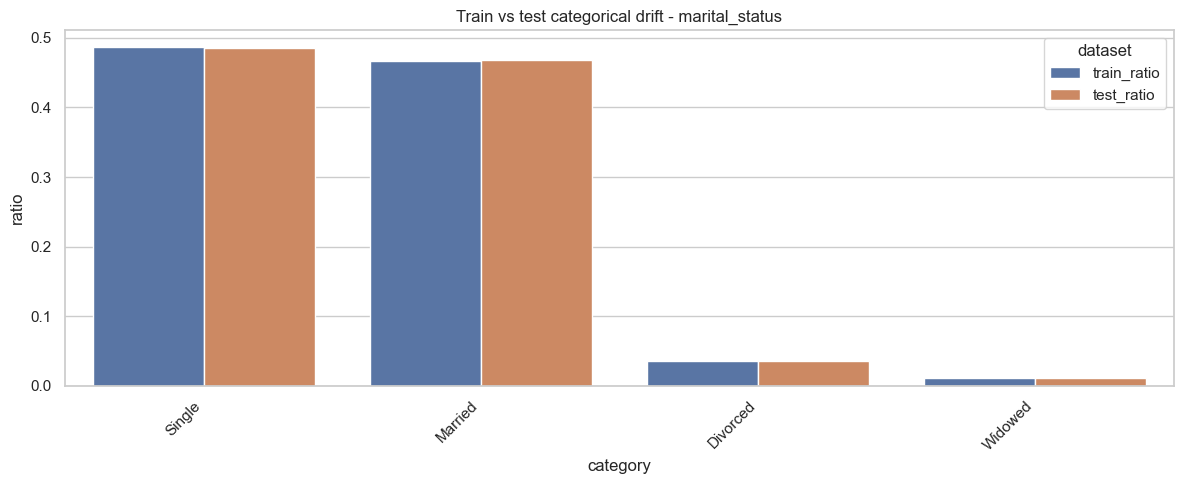

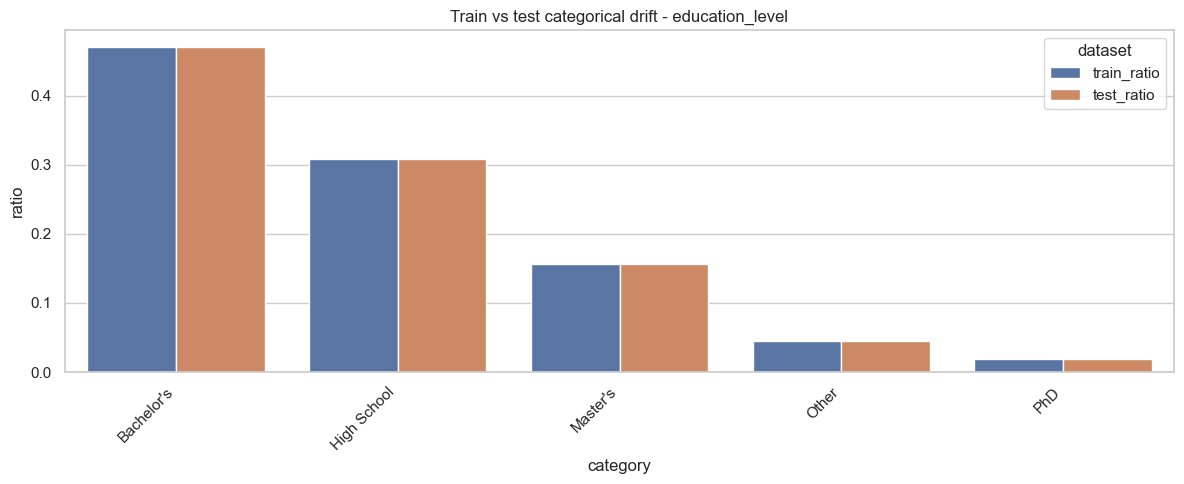


# EDA Summary

## Dataset overview
- Train shape: (593994, 13)
- Test shape: (254569, 12)
- Target column: loan_paid_back
- ID column: id
- Number of numeric features: 5
- Number of categorical features: 6
- Number of other features: 1
- sample_submission matches test ids: True

## Data quality
- Train duplicate rows: 0
- Test duplicate rows: 0
- Train duplicate IDs: 0
- Test duplicate IDs: 0
- Columns with missing values in train: 0
- Columns with missing values in test: 0
- Strange text value columns: 0
- Category formatting issue columns: 0

## Target analysis
- Imbalance label: heavily imbalanced
- Majority-class baseline: 0.7988
- Recommended validation: Use stratified split or stratified k-fold
- Metric focus: ROC-AUC, so modeling should output probabilities

## Feature insights
- Most promising numeric features: debt_to_income_ratio, credit_score, interest_rate, annual_income, loan_amount
- Most promising categorical features: employment_status, grade_subgrade, loan_purpose, ed

,file_type,file_name
0,table,data_dictionary.csv
1,table,numeric_summary.csv
2,table,categorical_summary.csv
3,table,train_test_shift_summary.csv
4,table,leakage_review.csv
5,table,feature_recommendations.csv
6,table,preprocessing_plan.csv
7,report,EDA_SUMMARY.md
8,report,DEVELOPER_BRIEF.md
9,report,preprocessing_recommendations.md


In [17]:
top_shifted_numeric = numeric_shift_summary.head(min(5, len(numeric_shift_summary)))["column"].tolist()
for col in top_shifted_numeric:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_df[col].dropna(), bins=30, stat="density", alpha=0.4, label="train")
    sns.histplot(test_df[col].dropna(), bins=30, stat="density", alpha=0.4, label="test")
    plt.title(f"Train vs test drift - {col}")
    plt.legend()
    save_plot(f"train_test_drift_numeric_{col}.png")

top_shifted_categorical = categorical_shift_summary.head(min(5, len(categorical_shift_summary)))["column"].tolist()
for col in top_shifted_categorical:
    train_freq = normalize_categorical(train_df[col]).value_counts(normalize=True)
    test_freq = normalize_categorical(test_df[col]).value_counts(normalize=True)

    all_categories = sorted(set(train_freq.index) | set(test_freq.index))
    plot_df = pd.DataFrame(
        {
            "category": all_categories,
            "train_ratio": train_freq.reindex(all_categories, fill_value=0).values,
            "test_ratio": test_freq.reindex(all_categories, fill_value=0).values,
        }
    ).sort_values("train_ratio", ascending=False).head(15)

    plot_df = plot_df.melt(
        id_vars="category",
        value_vars=["train_ratio", "test_ratio"],
        var_name="dataset",
        value_name="ratio"
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x="category", y="ratio", hue="dataset")
    plt.title(f"Train vs test categorical drift - {col}")
    plt.xticks(rotation=45, ha="right")
    save_plot(f"train_test_drift_categorical_{col}.png")

top_numeric_for_report = numeric_summary.head(5)["column"].tolist() if not numeric_summary.empty else []
top_categorical_for_report = categorical_summary.head(5)["column"].tolist() if not categorical_summary.empty else []
top_leakage_for_report = leakage_review["column"].head(10).tolist() if not leakage_review.empty else []

top_high_corr_pairs_for_report = high_corr_pairs.head(10)[["feature_a", "feature_b", "correlation"]] if not high_corr_pairs.empty else pd.DataFrame()

eda_summary_text = f"""
# EDA Summary

## Dataset overview
- Train shape: {train_df.shape}
- Test shape: {test_df.shape}
- Target column: {TARGET_COL}
- ID column: {ID_COL}
- Number of numeric features: {len(numeric_columns)}
- Number of categorical features: {len(categorical_columns)}
- Number of other features: {len(other_columns)}
- sample_submission matches test ids: {sample_submission_matches_test_ids}

## Data quality
- Train duplicate rows: {train_df.duplicated().sum()}
- Test duplicate rows: {test_df.duplicated().sum()}
- Train duplicate IDs: {train_df[ID_COL].duplicated().sum() if ID_COL in train_df.columns else "N/A"}
- Test duplicate IDs: {test_df[ID_COL].duplicated().sum() if ID_COL in test_df.columns else "N/A"}
- Columns with missing values in train: {(train_df.isna().sum() > 0).sum()}
- Columns with missing values in test: {(test_df.isna().sum() > 0).sum()}
- Strange text value columns: {len(strange_text_summary)}
- Category formatting issue columns: {len(category_format_issues)}

## Target analysis
- Imbalance label: {imbalance_label}
- Majority-class baseline: {majority_class_rate:.4f}
- Recommended validation: {validation_recommendation}
- Metric focus: ROC-AUC, so modeling should output probabilities

## Feature insights
- Most promising numeric features: {pretty_join(top_numeric_for_report)}
- Most promising categorical features: {pretty_join(top_categorical_for_report)}

## Train vs test comparison
- Strongly shifted columns: {pretty_join(strongly_shifted_columns)}
- Slightly shifted columns: {pretty_join(slightly_shifted_columns)}

## Leakage risk
- Columns to review for leakage: {pretty_join(top_leakage_for_report)}

## Highly correlated pairs
{top_high_corr_pairs_for_report.to_string(index=False) if not top_high_corr_pairs_for_report.empty else "No strongly correlated pairs above threshold."}

## Recommendations for modeling
- Drop columns: {pretty_join(drop_columns)}
- Review columns: {pretty_join(review_columns)}
- Numeric median imputation: {pretty_join(numeric_impute_columns)}
- Categorical imputation with 'Missing': {pretty_join(categorical_impute_columns)}
- One-hot encoding: {pretty_join(one_hot_columns)}
- Frequency or target encoding: {pretty_join(frequency_encode_columns)}
- Log transform: {pretty_join(log_transform_columns)}
- Clip outliers: {pretty_join(clip_outlier_columns)}
- Validation plan: stratified split or stratified k-fold

## Next steps for developer
1. Drop ID, constant and leakage-review columns first.
2. Build preprocessing pipeline that is identical for train and test.
3. Use predict_proba because the competition metric is ROC-AUC.
4. Start with a baseline model and compare stronger tree-based models next.
5. Watch columns with strong train/test shift and unseen categories.
"""
write_text("EDA_SUMMARY.md", eda_summary_text)
print(eda_summary_text)

developer_brief = f"""
# Developer brief

## Drop first
- {pretty_join(drop_columns)}

## Review for leakage or weak value
- {pretty_join(review_columns)}
- {pretty_join(leakage_columns)}

## Numeric preprocessing
- Median imputation
- Log transform for: {pretty_join(log_transform_columns)}
- Clip outliers for: {pretty_join(clip_outlier_columns)}

## Categorical preprocessing
- One-hot for: {pretty_join(one_hot_columns)}
- Frequency or target encoding for: {pretty_join(frequency_encode_columns)}

## Validation
- Stratified k-fold recommended

## Risks
- Strong train/test drift: {pretty_join(strongly_shifted_columns)}
- Unseen categories exist in some categorical features. Check categorical_shift_summary.csv.

## Promising features
- Numeric: {pretty_join(top_numeric_for_report)}
- Categorical: {pretty_join(top_categorical_for_report)}
"""
write_text("DEVELOPER_BRIEF.md", developer_brief)
print(developer_brief)

handoff_files = pd.DataFrame(
    {
        "file_type": [
            "table", "table", "table", "table", "table", "table", "table", "report", "report", "report"
        ],
        "file_name": [
            "data_dictionary.csv",
            "numeric_summary.csv",
            "categorical_summary.csv",
            "train_test_shift_summary.csv",
            "leakage_review.csv",
            "feature_recommendations.csv",
            "preprocessing_plan.csv",
            "EDA_SUMMARY.md",
            "DEVELOPER_BRIEF.md",
            "preprocessing_recommendations.md",
        ],
    }
)
display(handoff_files)
save_csv(handoff_files, "handoff_files_index.csv")